In [1]:
import pandas as pd
import numpy as np
import pickle
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import random
import networkx as nx
import matplotlib.image as mpimg
import torch
import torch.nn.functional as F
import importlib
import shap
import requests
import io
import sys
import re

from collections import defaultdict
from pathlib import Path
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
from sklearn.model_selection import train_test_split
from datetime import datetime
from lingam import VARLiNGAM
from matplotlib import gridspec
from IPython.display import display, Markdown, HTML
from matplotlib.ticker import FormatStrFormatter
from typing import Dict, Tuple
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import cross_val_score, KFold
from sentence_transformers import SentenceTransformer, util
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from bert_score import score
from dotenv import load_dotenv
from IPython.display import display, Markdown
from selenium import webdriver
from sklearn.metrics import roc_auc_score, roc_curve, precision_score, recall_score
from sklearn.metrics import make_scorer
from pathlib import Path
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder,OrdinalEncoder,StandardScaler,MinMaxScaler


load_dotenv()

openai_api_key = os.getenv("OPENAI_API_KEY")
groq_api_key = os.getenv("GROQ_API_KEY")

<br> <br>

####  Helper function to determine output folder based on persona

In [2]:
# Helper function to determine output folder based on persona
def get_output_folder_for_persona(persona: str, base_path: str = "../../llm_response/ai4i_2020") -> str:
    """
    Generate output folder path based on persona
    
    Args:
        persona: Either "data_scientist" or "operator"
        base_path: Base path for LLM responses
        
    Returns:
        Complete path with persona-specific subfolder
    """
    if persona == "data_scientist":
        return f"{base_path}/data_scientist"
    elif persona == "operator":
        return f"{base_path}/machine_operator"
    else:
        # Default fallback
        return f"{base_path}/{persona}"

print("✅ Helper function for persona-based paths loaded")

✅ Helper function for persona-based paths loaded


<br> <br> <br>

## Load dataset, feature engineering and pre-processing

In [4]:
# # Load the AI4I 2020 dataset
# print("📊 Loading AI4I 2020 Dataset for Causality Analysis")
# print("=" * 60)


# def feature_engineering(df):

#     # scaler = StandardScaler()
#     # label_encoder = LabelEncoder()
#     minmax_scaler = MinMaxScaler()
#     encoder = OrdinalEncoder(categories=[["L", "M", "H"]])

#     df.rename(
#         columns={
#             "Air temperature [K]": "Air_temperature",
#             "Process temperature [K]": "Process_temperature",
#             "Rotational speed [rpm]": "Rotational_speed",
#             "Torque [Nm]": "Torque",
#             "Tool wear [min]": "Tool_wear",
#             "Failure Type": "Failure_Type",
#         },
#         inplace=True,
#     )

#     # Engineered Features
#     df["Power_output"] = df["Torque"] * df["Rotational_speed"]
#     df["wear_torque_product"] = df["Tool_wear"] * df["Torque"]
#     df["Temp_difference"] = np.abs(df["Air_temperature"] - df["Process_temperature"])

#     # exclude_columns = ["Type", "Failure Type"]
#     mapping = {"L": 1, "M": 2, "H": 3}
#     df["Type_n"] = df["Type"].map(mapping)
#     df["Type_n"] = encoder.fit_transform(df[["Type"]]).astype(int)

#     exclude_columns = ["Failure_Type", "Target", "Type_n"]

#     df.drop(columns=["Product ID", "UDI", "Type"], inplace=True)

#     # Columns to scale
#     columns_to_scale = [col for col in df.columns if col not in exclude_columns]

#     df_minmax = df.copy()
#     df_minmax[columns_to_scale] = minmax_scaler.fit_transform(
#         df_minmax[columns_to_scale]
#     )
#     df_minmax = pd.concat(
#         [df_minmax[columns_to_scale], df_minmax[exclude_columns]], axis=1
#     )

#     return df_minmax


# # Load the predictive maintenance dataset
# # df_pm = pd.read_csv(os.path.join(paths['data_path'], 'ai4i_2020', 'predictive_maintenance.csv'))
# df_pm = pd.read_csv("../../data/ai4i_2020/predictive_maintenance.csv")


# # Count rows before filtering
# rows_before = len(df_pm)

# # Remove rows where Target is 1 and Failure_Type is "No Failure" --> (Noise)
# df_pm = df_pm[~((df_pm['Target'] == 1) & (df_pm['Failure Type'] == "No Failure"))]

# # Count rows after filtering
# rows_after = len(df_pm)
# print(f"📝 Removed {rows_before - rows_after} noise rows (Target=1 & Failure_Type='No Failure')")

# # Apply feature engineering
# df_processed = feature_engineering(df_pm)

# # Remove Random Failures (as discussed in previous analysis)
# df_processed = df_processed[df_processed['Failure_Type'] != 'Random Failures']

# print(f"📊 Dataset shape after preprocessing: {df_processed.shape}")
# print(f"🎯 Target distribution: {df_processed['Target'].value_counts().to_dict()}")
# print(f"📋 Available features: {list(df_processed.columns)}")

In [3]:
pd.read_csv("../../data/ai4i_2020/ai4i2020.csv")

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [4]:
# Load the AI4I 2020 dataset
print("📊 Loading AI4I 2020 Dataset for Causality Analysis")
print("=" * 60)


def feature_engineering(df):

    # scaler = StandardScaler()
    # label_encoder = LabelEncoder()
    minmax_scaler = MinMaxScaler()
    encoder = OrdinalEncoder(categories=[["L", "M", "H"]])

    df.rename(
        columns={
            "Air temperature [K]": "Air_temperature",
            "Process temperature [K]": "Process_temperature",
            "Rotational speed [rpm]": "Rotational_speed",
            "Torque [Nm]": "Torque",
            "Tool wear [min]": "Tool_wear",
            "Failure Type": "Failure_Type",
        },
        inplace=True,
    )

    # Engineered Features
    df["Power_output"] = df["Torque"] * df["Rotational_speed"]
    df["wear_torque_product"] = df["Tool_wear"] * df["Torque"]
    df["Temp_difference"] = np.abs(df["Air_temperature"] - df["Process_temperature"])

    # exclude_columns = ["Type", "Failure Type"]
    mapping = {"L": 1, "M": 2, "H": 3}
    df["Type_n"] = df["Type"].map(mapping)
    df["Type_n"] = encoder.fit_transform(df[["Type"]]).astype(int)

    exclude_columns = ["Failure_Type", "Target", "Type_n"]

    df.drop(columns=["Product ID", "UDI", "Type"], inplace=True)

    # Columns to scale
    columns_to_scale = [col for col in df.columns if col not in exclude_columns]

    df_minmax = df.copy()
    df_minmax[columns_to_scale] = minmax_scaler.fit_transform(
        df_minmax[columns_to_scale]
    )
    df_minmax = pd.concat(
        [df_minmax[columns_to_scale], df_minmax[exclude_columns]], axis=1
    )

    return df_minmax



df_pm = pd.read_csv("../../data/ai4i_2020/ai4i2020.csv")

# rename "Machine failure" to "Target"
df_pm.rename(columns={"Machine failure": "Target"}, inplace=True)

failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
mapping = {
    'TWF': 'Tool Wear Failure',
    'HDF': 'Heat Dissipation Failure',
    'PWF': 'Power Failure',
    'OSF': 'Overstrain Failure',
    'RNF': 'Random Failures'
}

df_pm = df_pm.copy()
has_failure = df_pm[failure_cols].sum(axis=1) > 0

# Use idxmax to pick the one-hot column, then map to human-readable labels;
# for rows with no flagged failure, set to 'No Failure'
df_pm['Failure Type'] = df_pm[failure_cols].idxmax(axis=1).map(mapping)
df_pm.loc[~has_failure, 'Failure Type'] = 'No Failure'

# Optionally drop the original one-hot columns
df_pm = df_pm.drop(columns=failure_cols)

display(df_pm.head())


# Count rows before filtering
rows_before = len(df_pm)

# Remove rows where Target is 1 and Failure_Type is "No Failure" --> (Noise)
df_pm = df_pm[~((df_pm['Target'] == 1) & (df_pm['Failure Type'] == "No Failure"))]

# Count rows after filtering
rows_after = len(df_pm)
print(f"📝 Removed {rows_before - rows_after} noise rows (Target=1 & Failure_Type='No Failure')")

# Apply feature engineering
df_processed = feature_engineering(df_pm)

# Remove Random Failures (as discussed in previous analysis)
df_processed = df_processed[df_processed['Failure_Type'] != 'Random Failures']

print(f"📊 Dataset shape after preprocessing: {df_processed.shape}")
print(f"🎯 Target distribution: {df_processed['Target'].value_counts().to_dict()}")
print(f"📋 Available features: {list(df_processed.columns)}")

📊 Loading AI4I 2020 Dataset for Causality Analysis


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


📝 Removed 9 noise rows (Target=1 & Failure_Type='No Failure')
📊 Dataset shape after preprocessing: (9973, 11)
🎯 Target distribution: {0: 9643, 1: 330}
📋 Available features: ['Air_temperature', 'Process_temperature', 'Rotational_speed', 'Torque', 'Tool_wear', 'Power_output', 'wear_torque_product', 'Temp_difference', 'Failure_Type', 'Target', 'Type_n']


In [5]:
df_processed["Failure_Type"].value_counts()

No Failure                  9643
Heat Dissipation Failure     115
Power Failure                 91
Overstrain Failure            78
Tool Wear Failure             46
Name: Failure_Type, dtype: int64

<br> <br> <br>


## Training Machine Learning Models




In [8]:
def train_model_crossval(model_type: str, X_train_balanced: np.ndarray, y_train_balanced: pd.Series, n_folds=10) -> Dict:
    try:
        model_type = model_type.lower()
        model_switch = {
            "randomforest": RandomForestClassifier(random_state=42),
            "xgboost": XGBClassifier(
                random_state=42,
                eval_metric="logloss",  # Specify evaluation metric to avoid warnings
            ),
            "lgbmclassifier": LGBMClassifier(
                random_state=42,
                boosting_type="gbdt",  # Gradient Boosting Decision Trees
                n_estimators=100,  # Number of boosting rounds
                learning_rate=0.1,  # Shrinkage rate
                max_depth=-1,  # Unlimited depth
            ),
            "catboost": CatBoostClassifier(
                random_state=42,
                iterations=100,  # Number of boosting iterations
                learning_rate=0.1,
                depth=6,
                verbose=False,  # Suppress verbose output
            ),
        }
        
        # Get the model based on model_type
        model = model_switch.get(model_type)
        
        if model is None:
            raise AttributeError("Invalid model type")
            
        # Set up k-fold cross-validation
        kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
        
        # Perform cross-validation
        cv_scores = cross_val_score(model, X_train_balanced, y_train_balanced, cv=kf, scoring='roc_auc')
        
        # Train the final model on the entire training set
        model.fit(X_train_balanced, y_train_balanced)
        
        # Return both the model and cross-validation results
        return {
            'model': model,
            'cv_scores': cv_scores,
            'mean_cv_score': np.mean(cv_scores),
            'std_cv_score': np.std(cv_scores)
        }

    except AttributeError as e:
        print(f"Error: {e}")
    except Exception as e:
        print(f"Unexpected error: {e}")
    
    return None



def exec_model_Youden_Index(model_type: str, X_train: np.ndarray, y_train: pd.Series, X_test: np.ndarray, y_test: pd.Series) -> Dict:

    try:
        # Train the model using cross-validation
        result = train_model_crossval(model_type, X_train, y_train)
        model = result['model']
        
        # Print cross-validation results
        print(f"Cross-validation results for {model_type}:")
        print(f"Mean ROC AUC: {result['mean_cv_score']:.4f} ± {result['std_cv_score']:.4f}")
        
        # Get class probabilities for the positive class
        y_proba = model.predict_proba(X_test)[:, 1]
        # Calculate the ROC AUC score
        auc_score = roc_auc_score(y_test, y_proba)
        # Normalize the AUC score
        normalized_auc = (auc_score - 0.5) / 0.5
        
        # Calculate ROC curve
        fpr, tpr, thresholds = roc_curve(y_test, y_proba)
        
        # Calculate Youden's index (J = Sensitivity + Specificity - 1 = TPR - FPR)
        youden_index = tpr - fpr
        # Find the optimal threshold that maximizes the Youden index
        optimal_idx = np.argmax(youden_index)
        optimal_threshold = thresholds[optimal_idx]
        
        # Calculate precision and recall at the optimal threshold
        y_pred = (y_proba >= optimal_threshold).astype(int)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        
        # Plot the ROC curve
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {auc_score:.3f})')
        # Mark the optimal threshold on the ROC curve
        plt.plot(fpr[optimal_idx], tpr[optimal_idx], 'ro', markersize=8, 
                 label=f'Optimal threshold (Youden Index)')
        plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
        plt.tick_params(axis='both', which='major', labelsize=16)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic (ROC) Curve')
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.show()

        # Print the results
        print(f"ROC AUC Score: {auc_score:.4f}")
        print(f"Normalized AUC Score: {normalized_auc:.4f}")
        print(f"Optimal Threshold (Youden Index): {optimal_threshold:.4f}")
        print(f"At optimal threshold - Precision: {precision:.4f}, Recall: {recall:.4f}")

        # Save the model
        with open(f"model/{model_type}.pkl", 'wb') as file:
            pickle.dump(model, file)

    except Exception as e:
        print(str(e))

    return print(f"Model {model_type} was trained successfully")

In [9]:
X = df_processed.drop(columns=["Target", "Failure_Type"])
# y = df_processed["Target"] # y = df["Failure_Type"]
y = df_processed[["Target", "Failure_Type"]]
X_train, X_test, y_train, y_test = train_test_split(X, y["Target"], test_size=0.2, random_state=42)

Cross-validation results for randomforest:
Mean ROC AUC: 0.9847 ± 0.0162


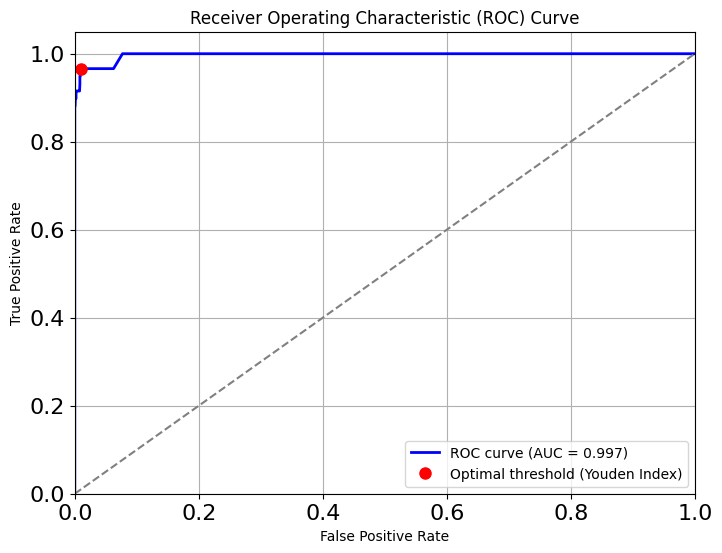

ROC AUC Score: 0.9972
Normalized AUC Score: 0.9943
Optimal Threshold (Youden Index): 0.2100
At optimal threshold - Precision: 0.7600, Recall: 0.9661
Model randomforest was trained successfully


In [10]:
exec_model_Youden_Index("randomforest", X_train, y_train, X_test, y_test)

Cross-validation results for xgboost:
Mean ROC AUC: 0.9891 ± 0.0053


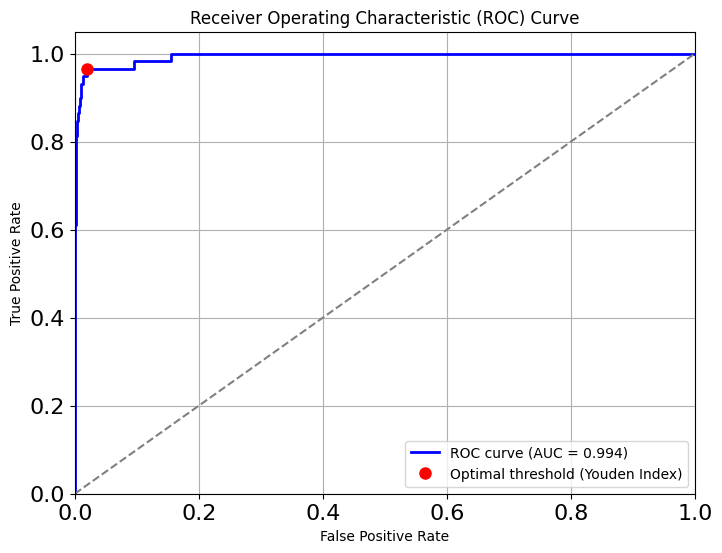

ROC AUC Score: 0.9940
Normalized AUC Score: 0.9879
Optimal Threshold (Youden Index): 0.0421
At optimal threshold - Precision: 0.5938, Recall: 0.9661
Model xgboost was trained successfully


In [11]:
exec_model_Youden_Index("xgboost", X_train, y_train, X_test, y_test)

[LightGBM] [Info] Number of positive: 244, number of negative: 6936
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000216 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1514
[LightGBM] [Info] Number of data points in the train set: 7180, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.033983 -> initscore=-3.347312
[LightGBM] [Info] Start training from score -3.347312
[LightGBM] [Info] Number of positive: 239, number of negative: 6941
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000178 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1514
[LightGBM] [Info] Number of data points in the train set: 7180, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.033287 -> initscore=-3.368738
[LightGBM] [Info] Start training from score -3.368738
[LightGBM] [Warning] N

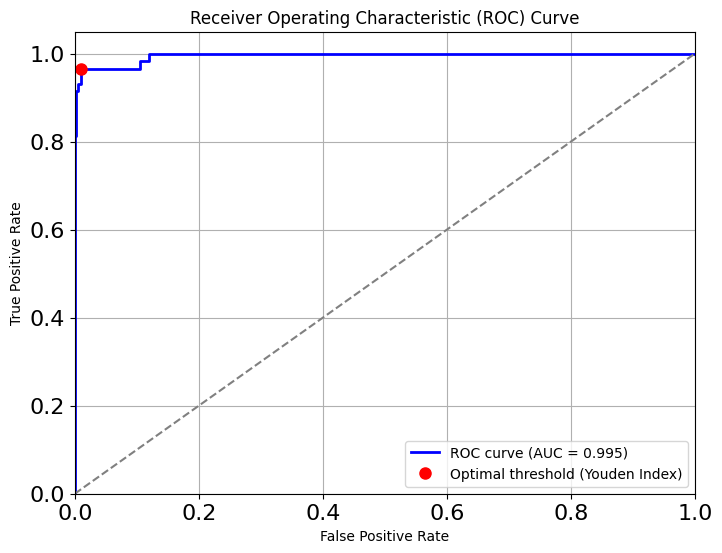

ROC AUC Score: 0.9954
Normalized AUC Score: 0.9909
Optimal Threshold (Youden Index): 0.0488
At optimal threshold - Precision: 0.7600, Recall: 0.9661
Model lgbmclassifier was trained successfully


In [12]:
exec_model_Youden_Index("lgbmclassifier", X_train, y_train, X_test, y_test)

Cross-validation results for catboost:
Mean ROC AUC: 0.9929 ± 0.0035


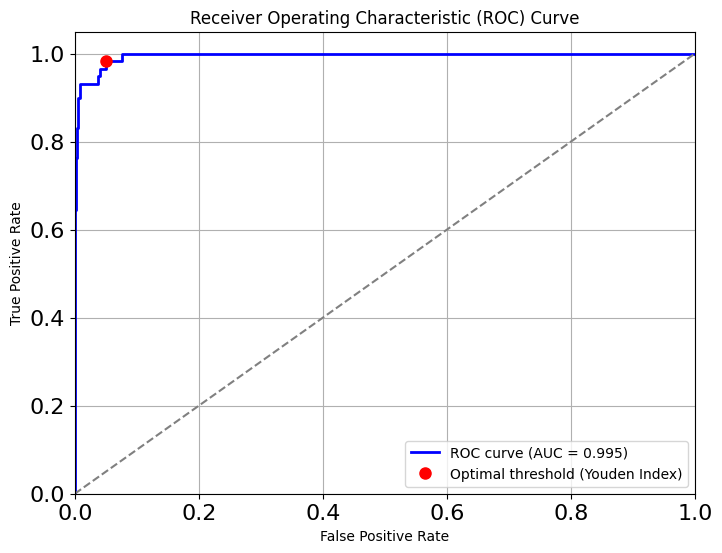

ROC AUC Score: 0.9953
Normalized AUC Score: 0.9906
Optimal Threshold (Youden Index): 0.0413
At optimal threshold - Precision: 0.3742, Recall: 0.9831
Model catboost was trained successfully


In [13]:
exec_model_Youden_Index("catboost", X_train, y_train, X_test, y_test)

<br> <br> <br>

## Taxonomy

In [7]:
def generate_taxonomy_with_groq(columns_list, api_key, model="llama3-70b-8192", output_file="groq_taxonomy.json"):
    output_file = f"{output_file}"
    headers = {"Authorization": f"Bearer {api_key}", "Content-Type": "application/json"}

    # API endpoint
    endpoint = "https://api.groq.com/openai/v1/chat/completions"

    # Create the prompt for the taxonomy
    prompt = f"""
    **Task**:  
    Create a hierarchical taxonomy for dataset features.

    **Instructions**:
    
    1. **Organize Features Hierarchically**:  
    - Group dataset features based on their semantic meaning and relationships.
    - The taxonomy should show clear parent-child relationships between features.

    2. **Output Must Be Valid JSON**:
    - Ensure the response is in **JSON format**.
    - No extra text or explanations.

    **Example Format**:
    {{
        "Type": [1, "Root"],
        "Temperature": [1, "Root"],
        "Air_temperature": [2, "Temperature"]
        "Air_temperature_combination": [3, "Air_temperature"]
        
    }}

    **Input Features**:
    {', '.join(columns_list)}
    """

    # Create the request payload
    payload = {
        "model": model,  # Using the model specified as parameter
        "messages": [
            {
                "role": "system",
                "content": "You are a data scientist who organizes features into taxonomies.",
            },
            {"role": "user", "content": prompt},
        ],
        "temperature": 0.2,
    }

    # Make the API call
    response = requests.post(endpoint, headers=headers, json=payload)

    if response.status_code == 200:
        result = response.json()
        content = result["choices"][0]["message"]["content"]

        # Extract JSON from the response
        json_match = re.search(r"{.*}", content, re.DOTALL)
        if json_match:
            taxonomy_json_str = json_match.group(0)
            taxonomy = json.loads(taxonomy_json_str)
        else:
            # If no JSON pattern found, try to parse the whole content
            try:
                taxonomy = json.loads(content)
            except:
                raise ValueError("Failed to parse JSON from API response")

        # Save to file
        with open(output_file, "w") as f:
            json.dump(taxonomy, f, indent=2)

        return taxonomy
    else:
        error_message = f"API request failed with status code {response.status_code}"
        try:
            error_details = response.json()
            error_message += f": {error_details}"
        except:
            pass
        raise Exception(error_message)


def generate_taxonomy_with_openai_with_feature_root(filename, features, root_features, openai_api_key):
    prompt = f"""
    **Task**:  
    Create a hierarchical taxonomy for dataset features.

    **Instructions**:
    
    1. **Organize Features Hierarchically**:  
    - Group dataset features based on their semantic meaning and relationships.
    - The taxonomy should show clear parent-child relationships between features.
    - The hierachy MUST NOT include features that are not existed in the dataset's features  
      Dataset's list of feature: {features} 
    -The roots of the hierarchy are {root_features}. These features can not have parents.


    2. **Output Must Be Valid JSON**:
    - Ensure the response is in **JSON format**.
    - No extra text or explanations.

    3. The hierarchy can be at any levels (e.g. 2,3,4,etc) but should be logical and meaningful.

    **Example Format**:
    {{
        "Type": [1, "Root"],
        "Temperature": [1, "Root"],
        "Air_temperature": [2, "Temperature"]

    }}

    **Input Features**:
    {json.dumps(features, indent=2)}
    """

    openai_url = "https://api.openai.com/v1/chat/completions"
    headers = {
        "Authorization": f"Bearer {openai_api_key}",
        "Content-Type": "application/json",
    }
    data = {
        "model": "gpt-4o",
        "messages": [
            {
                "role": "system",
                "content": "Respond only with valid JSON, no extra text.",
            },
            {"role": "user", "content": prompt},
        ],
        "response_format": {
            "type": "json_object"
        },  # ✅ Changed from "json" to "json_object"
        "temperature": 0,
    }

    response = requests.post(openai_url, headers=headers, json=data)

    if response.status_code == 200:
        raw_content = response.json()["choices"][0]["message"]["content"].strip()

        # print("🔍 Raw OpenAI Response:\n", raw_content)  # Debugging step

        # Extract only JSON if extra text is present
        json_match = re.search(r"\{.*\}", raw_content, re.DOTALL)
        if json_match:
            raw_content = json_match.group(0)  # Extract JSON only

        # Try to parse as JSON
        try:
            taxonomy = json.loads(raw_content)
        except json.JSONDecodeError:
            raise RuntimeError(
                f"OpenAI API returned an invalid JSON response:\n{raw_content}"
            )

        # Save taxonomy to a file
        with open(f"{filename}", "w") as f:
            json.dump(taxonomy, f, indent=2)

        return taxonomy
    else:
        raise RuntimeError(
            f"Error from OpenAI API: {response.status_code} {response.text}"
        )




def generate_taxonomy_with_openai(filename, features, openai_api_key):
    prompt = f"""
    **Task**:  
    Create a hierarchical taxonomy for dataset features.

    **Instructions**:
    
    1. **Organize Features Hierarchically**:  
    - Group dataset features based on their semantic meaning and relationships.
    - The taxonomy should show clear parent-child relationships between features.

    2. **Output Must Be Valid JSON**:
    - Ensure the response is in **JSON format**.
    - No extra text or explanations.

    3. The hierarchy can be at any levels (e.g. 2,3,4,etc) but should be logical and meaningful.

    **Example Format**:
    {{
        "Type": [1, "Root"],
        "Temperature": [1, "Root"],
        "Air_temperature": [2, "Temperature"]

    }}

    **Input Features**:
    {json.dumps(features, indent=2)}
    """

    openai_url = "https://api.openai.com/v1/chat/completions"
    headers = {
        "Authorization": f"Bearer {openai_api_key}",
        "Content-Type": "application/json",
    }
    data = {
        "model": "gpt-4o",
        "messages": [
            {
                "role": "system",
                "content": "Respond only with valid JSON, no extra text.",
            },
            {"role": "user", "content": prompt},
        ],
        "response_format": {
            "type": "json_object"
        },  # ✅ Changed from "json" to "json_object"
        "temperature": 0,
    }

    response = requests.post(openai_url, headers=headers, json=data)

    if response.status_code == 200:
        raw_content = response.json()["choices"][0]["message"]["content"].strip()

        # print("🔍 Raw OpenAI Response:\n", raw_content)  # Debugging step

        # Extract only JSON if extra text is present
        json_match = re.search(r"\{.*\}", raw_content, re.DOTALL)
        if json_match:
            raw_content = json_match.group(0)  # Extract JSON only

        # Try to parse as JSON
        try:
            taxonomy = json.loads(raw_content)
        except json.JSONDecodeError:
            raise RuntimeError(
                f"OpenAI API returned an invalid JSON response:\n{raw_content}"
            )

        # Save taxonomy to a file
        with open(f"{filename}", "w") as f:
            json.dump(taxonomy, f, indent=2)

        return taxonomy
    else:
        raise RuntimeError(
            f"Error from OpenAI API: {response.status_code} {response.text}"
        )



def format_taxonomy(taxonomy_json):
    """Formats a hierarchical taxonomy into a tree-like string."""
    if isinstance(taxonomy_json, str):
        taxonomy_json = json.loads(taxonomy_json)  # Parse JSON string if needed

    # Build tree structure
    tree = defaultdict(list)
    for feature, (_, parent) in taxonomy_json.items():
        tree[parent].append(feature)

    def display_tree(parent="Root", level=0):
        """Recursively formats the tree structure with icons and connectors."""
        if parent not in tree:
            return ""

        result = ""
        for idx, child in enumerate(tree[parent]):
            is_parent = child in tree  # Check if child has further children
            icon = (
                "📂" if is_parent else "📄"
            )  # Folder for parents, file for leaf nodes
            connector = (
                "└── " if idx == len(tree[parent]) - 1 else "├── "
            )  # Tree connectors
            result += "  " * level + connector + f"{icon} {child}\n"
            result += display_tree(child, level + 1)  # Recursive call for children

        return result

    return f"\n📌 **Taxonomy Structure:**\n\n{display_tree('Root')}".strip()


def get_taxonomy_paths(taxonomy_json, node_names):
    """Returns hierarchical paths for given nodes in a taxonomy."""
    if isinstance(taxonomy_json, str):
        taxonomy_json = json.loads(taxonomy_json)  # Parse JSON if it's a string

    # Reverse lookup: Map each child to its parent
    child_to_parent = {child: parent for child, (_, parent) in taxonomy_json.items()}

    def get_path(node):
        """Recursively constructs the hierarchy path for a node."""
        path = [node]
        while node in child_to_parent and child_to_parent[node] != "Root":
            node = child_to_parent[node]
            path.append(node)
        return " --> ".join(reversed(path))  # Reverse to get correct hierarchy order

    return {node: get_path(node) for node in node_names}


In [8]:
df_processed.columns.to_list()

['Air_temperature',
 'Process_temperature',
 'Rotational_speed',
 'Torque',
 'Tool_wear',
 'Power_output',
 'wear_torque_product',
 'Temp_difference',
 'Failure_Type',
 'Target',
 'Type_n']

In [9]:
llama3_taxonomy = generate_taxonomy_with_groq(columns_list=df_processed.columns, api_key=groq_api_key, model="llama-3.3-70b-versatile", output_file="taxonomy/llama3.json")
print(format_taxonomy(llama3_taxonomy))

📌 **Taxonomy Structure:**

├── 📂 Type
  └── 📄 Type_n
├── 📂 Temperature
  ├── 📂 Air_temperature
    └── 📄 Temp_difference
  └── 📄 Process_temperature
├── 📂 Mechanical
  ├── 📄 Rotational_speed
  ├── 📂 Torque
    └── 📄 wear_torque_product
  ├── 📄 Power_output
  └── 📄 Tool_wear
└── 📂 Failure
  ├── 📄 Failure_Type
  └── 📄 Target


In [18]:
gemma2_taxonomy = generate_taxonomy_with_groq(columns_list=df_processed.columns, api_key=groq_api_key, model="gemma2-9b-it", output_file="taxonomy/gemma2.json")
print(format_taxonomy(gemma2_taxonomy))

📌 **Taxonomy Structure:**

├── 📄 Type
├── 📂 Process
  └── 📄 Process_temperature
├── 📄 Target
├── 📄 Failure_Type
├── 📂 Performance
  ├── 📄 Rotational_speed
  ├── 📄 Torque
  └── 📄 Power_output
├── 📂 Wear
  └── 📂 Tool_wear
    └── 📄 wear_torque_product
├── 📂 Temperature
  └── 📂 Air_temperature
    └── 📄 Temp_difference
└── 📄 Type_n


In [20]:
# deepseek_taxonomy = generate_taxonomy_with_groq(columns_list=df_processed.columns, api_key=groq_api_key, model="deepseek-r1-distill-llama-70b", output_file="taxonomy/deepseek.json")
# print(format_taxonomy(deepseek_taxonomy))

In [21]:
gpt4o_taxonomy = generate_taxonomy_with_openai(filename="taxonomy/gpt4o.json", features=df_processed.columns.tolist(), openai_api_key=openai_api_key)
print(format_taxonomy(gpt4o_taxonomy))

📌 **Taxonomy Structure:**

├── 📂 Machine_Parameters
  ├── 📂 Temperature
    ├── 📄 Air_temperature
    ├── 📄 Process_temperature
    └── 📄 Temp_difference
  ├── 📂 Mechanical
    ├── 📄 Rotational_speed
    ├── 📄 Torque
    └── 📄 Tool_wear
  └── 📂 Derived_Metrics
    ├── 📄 Power_output
    └── 📄 wear_torque_product
└── 📂 Failure_Analysis
  ├── 📄 Failure_Type
  ├── 📄 Target
  └── 📄 Type_n


In [22]:
excluded_columns = ["Power_output", "wear_torque_product", "Temp_difference"]
root_features = [col for col in df_processed.columns if col not in excluded_columns]
gpt4o_taxonomy_with_feature_roow = generate_taxonomy_with_openai_with_feature_root(filename="taxonomy/gpt4o_with_feature_root.json", 
                                                                                   features=df_processed.columns.tolist(), 
                                                                                   root_features = root_features,
                                                                                   openai_api_key=openai_api_key)

print(format_taxonomy(gpt4o_taxonomy))

📌 **Taxonomy Structure:**

├── 📂 Machine_Parameters
  ├── 📂 Temperature
    ├── 📄 Air_temperature
    ├── 📄 Process_temperature
    └── 📄 Temp_difference
  ├── 📂 Mechanical
    ├── 📄 Rotational_speed
    ├── 📄 Torque
    └── 📄 Tool_wear
  └── 📂 Derived_Metrics
    ├── 📄 Power_output
    └── 📄 wear_torque_product
└── 📂 Failure_Analysis
  ├── 📄 Failure_Type
  ├── 📄 Target
  └── 📄 Type_n


<br> <br> 

## Load machine learning models

In [21]:
def load_ml_models(path):
    with open(f"{path}/randomforest.pkl", "rb") as f:
        randomforest_model = pickle.load(f)

    with open(f"{path}/xgboost.pkl", "rb") as f:
        xgboost_model = pickle.load(f)

    with open(f"{path}/catboost.pkl", "rb") as f:
        catboost_model = pickle.load(f)

    with open(f"{path}/lgbmclassifier.pkl", "rb") as f:
        lgbmclassifier_model = pickle.load(f)

    return randomforest_model, xgboost_model, catboost_model, lgbmclassifier_model


# ml_models_path = '../../model/ai4i_2020'
ml_models_path = 'model/'
randomforest_model, xgboost_model, catboost_model, lgbmclassifier_model = load_ml_models(path=ml_models_path)


In [22]:
def sample_diverse_failure_types(df_target_1, number_sample=5, random_seed=42):
    random.seed(random_seed)  # Set seed for reproducibility
    np.random.seed(random_seed)
    
    # Get unique failure types
    failure_types = df_target_1['Failure_Type'].unique()
    
    # Dictionary to store sampled rows for each failure type
    sampled_rows_by_type = {}
    
    # Sample rows for each failure type
    for failure_type in failure_types:
        
        # Filter rows for current failure type
        failure_type_rows = df_target_1[df_target_1['Failure_Type'] == failure_type]
        available_rows = len(failure_type_rows)       
        
        # Get unique Type_n values for this failure type
        unique_type_n = failure_type_rows['Type_n'].unique()

        
        # If we have multiple Type_n values, ensure diversity
        if len(unique_type_n) > 1:
            sampled_rows_list = []
            
            # Calculate how many samples per Type_n
            samples_per_type_n = max(1, number_sample // len(unique_type_n))
            remaining_samples = number_sample % len(unique_type_n)                       
            
            # Sample from each Type_n value
            for i, type_n_val in enumerate(unique_type_n):
                type_n_rows = failure_type_rows[failure_type_rows['Type_n'] == type_n_val]
                
                # Determine sample size for this Type_n
                current_sample_size = samples_per_type_n
                if i < remaining_samples:  # Distribute remaining samples
                    current_sample_size += 1
                
                # Don't sample more than available
                current_sample_size = min(current_sample_size, len(type_n_rows))
                
                if current_sample_size > 0:
                    sampled_type_n_rows = type_n_rows.sample(n=current_sample_size, random_state=random_seed + i)
                    sampled_rows_list.append(sampled_type_n_rows)                    
            
            # Combine all sampled rows for this failure type
            if sampled_rows_list:
                sampled_rows = pd.concat(sampled_rows_list, ignore_index=False)
                
                # If we still need more samples and have remaining rows
                current_total = len(sampled_rows)
                if current_total < number_sample and current_total < available_rows:
                    # Get remaining rows not already sampled
                    remaining_rows = failure_type_rows.drop(sampled_rows.index)
                    additional_needed = min(number_sample - current_total, len(remaining_rows))
                    
                    if additional_needed > 0:
                        additional_samples = remaining_rows.sample(n=additional_needed, random_state=random_seed + 100)
                        sampled_rows = pd.concat([sampled_rows, additional_samples], ignore_index=False)                       
            else:
                # Fallback to regular sampling
                sample_size = min(number_sample, available_rows)
                sampled_rows = failure_type_rows.sample(n=sample_size, random_state=random_seed)
                
        else:
            # Single Type_n value or no Type_n diversity - use regular sampling
            sample_size = min(number_sample, available_rows)
            sampled_rows = failure_type_rows.sample(n=sample_size, random_state=random_seed)
        
        sampled_rows_by_type[failure_type] = sampled_rows
        
        # Show final results for this failure type
        final_type_n_dist = sampled_rows['Type_n'].value_counts().sort_index()
    
    # Create a combined dataframe from all sampled rows
    all_sampled_rows = pd.concat(sampled_rows_by_type.values(), ignore_index=False)
    
    # Sort by failure type for better organization
    all_sampled_rows = all_sampled_rows.sort_values(['Failure_Type', 'Type_n']) 
    
    return all_sampled_rows

# Test the method with different sample sizes
number_rows = 10
df_target_1 = df_processed[df_processed['Target'] == 1]
all_sampled_rows = sample_diverse_failure_types(df_target_1, number_sample=number_rows, random_seed=42)
display(all_sampled_rows)

,Air_temperature,Process_temperature,Rotational_speed,Torque,Tool_wear,Power_output,wear_torque_product,Temp_difference,Failure_Type,Target,Type_n
4621,0.836957,0.679012,0.100698,0.648352,0.687747,0.645117,0.537916,0.133333,Heat Dissipation Failure,1,0
4270,0.793478,0.641975,0.094878,0.662088,0.608696,0.654340,0.485422,0.155556,Heat Dissipation Failure,1,0
4831,0.891304,0.777778,0.115250,0.696429,0.118577,0.713152,0.099109,0.200000,Heat Dissipation Failure,1,0
4720,0.880435,0.740741,0.107683,0.553571,0.758893,0.547113,0.513257,0.155556,Heat Dissipation Failure,1,1
4391,0.750000,0.543210,0.116414,0.656593,0.047431,0.669808,0.037534,0.066667,Heat Dissipation Failure,1,1
4618,0.836957,0.691358,0.097206,0.684066,0.648221,0.680674,0.532848,0.155556,Heat Dissipation Failure,1,1
4427,0.771739,0.543210,0.122817,0.619505,0.422925,0.634356,0.317167,0.022222,Heat Dissipation Failure,1,1
4565,0.804348,0.629630,0.062282,0.703297,0.098814,0.664597,0.083348,0.111111,Heat Dissipation Failure,1,2
4251,0.782609,0.641975,0.109430,0.710165,0.399209,0.722263,0.339789,0.177778,Heat Dissipation Failure,1,2
3829,0.760870,0.641975,0.115250,0.612637,0.513834,0.619541,0.381403,0.222222,Heat Dissipation Failure,1,2


<br> <br> <br>

## Generate Expalnation, actionable recommendation and evaluatre them for Data Scientist


In [ ]:
import pandas as pd
import numpy as np
import pickle
import os
import sys
import json
import random
import re
import openai
import groq
from pathlib import Path
from typing import Dict, Any, List, Literal, Optional, Tuple
from sentence_transformers import SentenceTransformer, util
from nltk.stem import PorterStemmer
import nltk
from IPython.display import display, Markdown
from dotenv import load_dotenv

# Download required NLTK data
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

# Add src to path and import utilities
# sys.path.append(str(Path().resolve().parent / "src"))
# from utils import (
#     feature_engineering,
#     extract_explanation_and_recommendation,
#     load_ml_models,
#     failure_type_description
# )
# from llm import generate_explantion_for_all_rows

# Load environment variables
load_dotenv()
openai_api_key = os.getenv("OPENAI_API_KEY")
groq_api_key = os.getenv("GROQ_API_KEY")



In [ ]:
def failure_type_description(failure_type, type_n=0):
    if failure_type == "Tool Wear Failure":
        description = "Tool wear is between 200 and 240 so the machine fails and the failure type is **Tool wear Failure**"
        important_parts_description = "Tool wear is between 200 and 240, Machine fails, Failure type, Tool Wear Failure"
    elif failure_type == "Heat Dissipation Failure":
        description = "temp_difference is less than 8.6 K and the rotational speed is less than 1380 so that the machine fails and the failure type is **Heat Dissipation Failure**"
        important_parts_description = "Temperature difference is less than 8.6 K, Rotational speed is less than 1380, Failure type, Heat Dissipation Failure"
    elif failure_type == "Power Failure":
        description = "if power_output < 3500 or power_output > 9000 then the machine fails and the failure type is **Power Failure**"
        important_parts_description = "Power output is less than 3500 or greater than 9000, Power output is less than 3500, Power output is greater than 9000, Failure type, Power Failure"
    elif failure_type == "Overstrain Failure":
        if type_n == 0:
            description = "The product type is L and the product of tool wear to torque exceeds 11000 so, the machine fails and the failure type is **Overstrain Failure**"
            important_parts_description = "Product type is L, Tool wear × Torque > 11,000, Machine fails, Failure type, Overstrain Failure"
        elif type_n == 1:
            description = "The product type is M and the product of tool wear to torque exceeds 12000 so, the machine fails and the failure type is **Overstrain Failure**"
            important_parts_description = "Product type is M, Tool wear × Torque > 12,000, Machine fails, Failure type, Overstrain Failure"
        elif type_n == 2:
            description = "The product type is H and the product of tool wear to torque exceeds 13000 so, the machine fails and the failure type is **Overstrain Failure**"
            important_parts_description = "Product type is H, Tool wear × torque > 13,000, Machine fails, Failure type, Overstrain Failure"
    else:
        description = "The machine fails based on an unknown reason and the failure type is Random Failures"
        important_parts_description = "Machine fails, Reason unknown, Failure type, Random Failures"

    return description, important_parts_description


def recom_act_tool_wear(persona):
    if persona == "data_scientist":
        recommendation = """
            A) Develop hybrid TCN-BiLSTM models to predict wear trends using vibration, force, and temperature signals.
            B) Deploy models that trigger parameter optimization (feed, speed) in real-time to extend tool life.
        """
    elif persona == "operator":
        recommendation = """
            A) Monitor tool condition using the dashboard. Follow system prompts to adjust feed rate or spindle speed when tool wear exceeds thresholds.
            B) Replace or report worn tools based on predefined wear indicators or alerts.
        """      
    else:
        recommendation = """
            A) Deploy a hybrid Temporal Convolutional Network (TCN) and Bidirectional Long Short-Term Memory (BiLSTM) predictive model to facilitate real-time monitoring of tool wear and enable adaptive adjustments to machining parameters, such as feed rate and spindle speed, to prolong tool lifespan.
            B) Optimize the geometry of the tool, including features like rake angle and nose radius, to minimize wear rates effectively.
            """
    return recommendation


def recom_act_heat_dissipation(persona):
    if persona == "data_scientist":
        recommendation = """
            A) Analyze thermal sensor data to detect inefficient cooling or early overheating events.
            B) Build models that correlate machining parameters with heat profiles to suggest optimal cooling strategies.
        """
    elif persona == "operator":
        recommendation = """
            A) Ensure MQL systems are filled with coolant and functioning. Check nozzle positions regularly for proper coolant access.
            B) Watch for heat alerts from sensors and pause operations if temperatures exceed safe levels.
        """
    else:
        recommendation = """
        A) Use minimum quantity lubrication (MQL) with nanofluids to enhance heat transfer efficiency. Integrate thermal sensors to monitor temperature gradients and adjust cooling dynamically

        B) Use cutting tools with surface features designed to enhance coolant access and improve heat dissipation from the cutting zone, preventing overheating when temperature differences and speeds fall below the specified thresholds.

        """
    return recommendation


def recom_act_power(persona):
    if persona == "data_scientist":
        recommendation = """
            A) Train Random Forest or regression models to detect abnormal power usage and recommend preventive action.
            B) Use time-series models to forecast torque and rotation anomalies that indicate possible failures.
        """
    elif persona == "operator": 
        recommendation = """
            A) Use the machine interface to track power usage. Follow alerts or color-coded indicators to reduce loads or pause processes.
            B) Respond to maintenance notifications when torque or power values are outside the normal range.
        """
    else:
        recommendation = """
        A) Deploy a real-time power monitoring system integrated with machine learning algorithms, such as Random Forest, to predict and regulate power consumption, ensuring it remains within the safe operational thresholds.
        
        B) Implement a predictive maintenance framework utilizing machine learning models to continuously monitor torque and rotational speed, enabling the early detection of power deviations and facilitating dynamic adjustments to maintain power within the defined range of 3500–9000 W.
        """
    return recommendation


def recom_act_overstrain(persona):
    if persona == "data_scientist":
        recommendation = """
            A) Analyze stress/strain sensor data to predict mechanical failure risk.
            B) Develop control logic that recommends operation pauses or speed adjustments based on torque load predictions.
        """
    elif persona == "operator":
        recommendation="""
            A) Operate within recommended torque and speed limits. Be cautious during heavy-load operations.
            B) Report any unusual vibrations or strain alarms to maintenance.
        """
    else:
        recommendation = """
        A) Employ finite element analysis (FEA) to identify critical stress points in the system and implement stress-relief heat treatments to mitigate the risk of overstrain.

        B) Integrate wear-resistant coatings in conjunction with torque-limiting algorithms to effectively reduce the likelihood of overstrain and enhance the durability of the manufacturing process.
        """
    return recommendation


def switch_recommendation_action(failure_type, persona):
    match failure_type:
        case "Tool Wear Failure":
            return recom_act_tool_wear(persona)
        case "Heat Dissipation Failure":
            return recom_act_heat_dissipation(persona)
        case "Power Failure":
            return recom_act_power(persona)
        case "Overstrain Failure":
            return recom_act_overstrain(persona)
        case _:
            return "No recommendation available for this failure type."


def extract_explanation_and_recommendation(md_file_path, random_row_index_id, df_target_1, persona="data_scientist"):
    """
    Extract explanation and recommendation from a Markdown file.

    Parameters:
    md_file_path (str): Path to the Markdown file

    Returns:
    tuple: (explanation, recommendation) as strings
    """
    try:
        with open(md_file_path, "r", encoding="utf-8") as file:
            content = file.read()
    except Exception as e:
        print(f"Error reading file {md_file_path}: {str(e)}")
        return "", ""

    lines = content.split("\n")

    explanation = ""
    recommendation = ""

    # Track which section we're in
    current_section = None

    for i, line in enumerate(lines):
        if "Explanation of the Failure" in line:
            current_section = "explanation"
            continue
        elif "Actionable Recommendation" in line:
            current_section = "recommendation"
            continue
        elif line.startswith("###") or line.startswith("##"):  # New section
            current_section = None
            continue

        # Skip empty lines or section dividers
        if not line.strip() or line.strip() in ["", "---"]:
            continue

        # Collect content based on current section
        if current_section == "explanation" and line.strip():
            explanation += " " + line.strip()
        elif current_section == "recommendation" and line.strip():
            recommendation += " " + line.strip()

    # Clean up the collected text
    explanation = explanation.strip()
    recommendation = recommendation.strip()
    failure_type = df_target_1.loc[random_row_index_id]["Failure_Type"]
    ground_truth = switch_recommendation_action(failure_type=failure_type, persona=persona)

    return explanation, recommendation, failure_type, ground_truth



In [ ]:
# -------------------------------------------------------------------------------------------------------------------------------------------------------
# -------------------------------------------------------------------------------------------------------------------------------------------------------
# -------------------------------------------------------------------------------------------------------------------------------------------------------

# ************************************************************** SHAP Feature Importance ****************************************************************


def generate_shap_values(model, 
                         random_sample, 
                         image_name, 
                         combined_feature_importance_name, 
                         top_n_features=3, 
                         class_idx=1, 
                         x_axis_labelsize=15, 
                         y_axis_labelsize=15, 
                         off_switch=False,):
    
    # Generate SHAP values for the sample
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(random_sample)

    # Handle SHAP values based on their structure and model type
    if isinstance(shap_values, list):
        # For models that return a list of arrays (like RF, XGB, LGBM for binary classification)
        feature_importance = np.abs(shap_values[class_idx]).mean(axis=0)
    else:
        # For models that return a single array
        feature_importance = np.abs(shap_values).mean(axis=0)

    # Create DataFrame with feature importances
    shap_feature_importance = pd.DataFrame(
        {"feature": random_sample.columns, "importance": feature_importance}
    )
    shap_feature_importance = shap_feature_importance.sort_values(
        "importance", ascending=False
    )

    # Display the top N important features in a DataFrame
    combined_feature_importance = pd.DataFrame(
        {
            "feature": shap_feature_importance["feature"][:top_n_features].tolist(),
            "importance": shap_feature_importance["importance"][
                :top_n_features
            ].tolist(),
        }
    ).sort_values("importance", ascending=False)

    # Save the combined feature importance DataFrame to a JSON file
    combined_feature_importance.to_json(f"../../json/ai4i_2020/{combined_feature_importance_name}.json", orient="records")

    # Get prediction probabilities for the sample
    pred_shap = model.predict_proba(random_sample)[0]

    # Plot the top features and their SHAP values
    plt.figure(figsize=(10, 6))
    plt.barh(
        shap_feature_importance["feature"][:top_n_features][::-1],
        shap_feature_importance["importance"][:top_n_features][::-1],
    )
    # plt.title(f"Top {top_n_features} Important Features from {combined_feature_importance_name}", fontsize=18)
    plt.title(f"Top {top_n_features} Important Features", fontsize=15)
    # plt.xlabel("SHAP Value (absolute)", fontsize=16)

    # Set different font sizes for x-axis and y-axis
    plt.tick_params(
        axis="x", which="major", labelsize=x_axis_labelsize
    )  # X-axis font size
    plt.tick_params(
        axis="y", which="major", labelsize=y_axis_labelsize
    )  # Y-axis font size

    # Format x-axis to have only 2 decimal places
    plt.gca().xaxis.set_major_formatter(FormatStrFormatter("%.2f"))

    plt.tight_layout()
    plt.savefig(image_name)

    if off_switch:
        plt.close()
    else:
        plt.show()

    return shap_values, pred_shap, combined_feature_importance


# -------------------------------------------------------------------------------------------------------------------------------------------------------
# -------------------------------------------------------------------------------------------------------------------------------------------------------
# -------------------------------------------------------------------------------------------------------------------------------------------------------

# ************************************************* Display Causality **************************************************

def display_causality_among_features_and_target(causal_graph, 
                                                features_to_analyze, 
                                                combined_feature_importance, 
                                                edge_threshold=None, 
                                                use_edge_threshold=False, 
                                                draw_label=True, 
                                                node_font_size=9, 
                                                node_size=1500, 
                                                save_path=None, 
                                                off_switch=False,):

    with open(f"{causal_graph}", "r") as file:
        causal_graph_data = json.load(file)

    # Create a directed graph
    G = nx.DiGraph()

    # Add nodes and collect edges
    G.add_node("Target", type="target")
    for feature in features_to_analyze:
        G.add_node(feature, type="feature")

    # Process edges
    edges_info = []
    target_edges_info = []

    # Filter threshold for edge visibility - only show stronger effects
    edge_threshold = edge_threshold

    for edge in causal_graph_data:
        source = edge["source_feature"]
        target = edge["target_feature"]
        effect = round(edge["effect_strength"], 2)

        if (
            (source in features_to_analyze or source == "Target")
            and (target in features_to_analyze or target == "Target")
            and (
                not use_edge_threshold
                or (abs(effect) >= edge_threshold and abs(effect) != 0.0)
            )
        ):
            is_target_edge = source == "Target" or target == "Target"
            edge_data = {
                "source": source,
                "target": target,
                "effect_strength": effect,
                "is_target": is_target_edge,
            }

            # Store the effect
            G.add_edge(
                source,
                target,
                weight=abs(effect),
                effect=effect,
                is_target=is_target_edge,
            )

            if is_target_edge:
                target_edges_info.append(edge_data)
            else:
                edges_info.append(edge_data)

    # Create DataFrame for edges
    all_edges_info = edges_info + target_edges_info
    causality_df = (
        pd.DataFrame(all_edges_info)
        if all_edges_info
        else pd.DataFrame(columns=["source", "target", "effect_strength", "is_target"])
    )

    # Set node attributes with configurable size
    feature_importance_dict = combined_feature_importance.set_index("feature")[
        "importance"
    ].to_dict()
    node_attrs = {}

    for node in G.nodes():
        if node == "Target":
            node_attrs[node] = {
                "size": node_size,  # Use parameter instead of fixed value
                "color": "#FF5555",  # Red for target
                "label": "Target",
                "importance": 1.0,
            }
        else:
            importance = feature_importance_dict.get(node, 0.01)
            node_attrs[node] = {
                "size": node_size,  # Use parameter instead of fixed value
                "color": "#5599FF",  # Blue for features
                "label": node,
                "importance": importance,
            }

    # Set up the plot with a clear background
    plt.figure(figsize=(14, 10), facecolor="white")

    # Choose optimal layout
    pos = nx.spring_layout(G, k=1.0, iterations=100, seed=42)

    # Improved node separation algorithm
    def get_node_radius(node):
        return np.sqrt(node_attrs[node]["size"] / np.pi) / 100

    # Apply force-directed algorithm to reduce node overlaps
    for _ in range(100):  # More iterations for better convergence
        displacement = {node: np.array([0.0, 0.0]) for node in G.nodes()}

        # Calculate repulsive forces
        for node1 in G.nodes():
            for node2 in G.nodes():
                if node1 != node2:
                    delta = np.array(pos[node1]) - np.array(pos[node2])
                    distance = max(0.01, np.linalg.norm(delta))

                    # Calculate repulsion based on node sizes
                    min_distance = (
                        get_node_radius(node1) + get_node_radius(node2) + 0.05
                    )

                    if distance < min_distance:
                        # Normalize direction vector
                        direction = (
                            delta / distance if distance > 0 else np.array([1.0, 0.0])
                        )
                        # Force is stronger when nodes are closer
                        force = min(0.1, (min_distance - distance) / min_distance) * 0.2
                        displacement[node1] += direction * force
                        displacement[node2] -= direction * force

        # Apply displacements
        for node in G.nodes():
            if node != "Target":  # Keep target node fixed
                pos[node] = np.array(pos[node]) + displacement[node]

    # Draw nodes with clear boundaries
    node_sizes = [node_attrs[node]["size"] for node in G.nodes()]
    node_colors = [node_attrs[node]["color"] for node in G.nodes()]
    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=node_sizes,
        node_color=node_colors,
        alpha=0.8,
        edgecolors="black",
        linewidths=1.5,
    )

    # Separate edges by type
    regular_edges = [
        (u, v) for u, v, d in G.edges(data=True) if not d.get("is_target", False)
    ]
    target_edges = [
        (u, v) for u, v, d in G.edges(data=True) if d.get("is_target", True)
    ]

    # Draw regular edges with clearer styling
    if regular_edges:
        regular_weights = [
            min(3, max(1, abs(G[u][v]["effect"]) * 2)) for u, v in regular_edges
        ]
        regular_colors = [
            "#DD8888" if G[u][v]["effect"] < 0 else "#88DD88" for u, v in regular_edges
        ]
        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=regular_edges,
            width=regular_weights,
            edge_color=regular_colors,
            arrowsize=12,
            arrowstyle="->",
            connectionstyle="arc3,rad=0.1",
            alpha=0.7,
        )

    # Draw target edges with more prominent style
    if target_edges:
        target_weights = [
            min(5, max(2, abs(G[u][v]["effect"]) * 4)) for u, v in target_edges
        ]
        target_colors = [
            "#9966CC" if G[u][v]["effect"] < 0 else "#FF9900" for u, v in target_edges
        ]
        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=target_edges,
            width=target_weights,
            edge_color=target_colors,
            arrowsize=15,
            arrowstyle="->",
            connectionstyle="arc3,rad=0.2",
        )

    # Draw labels with better positioning and offset from nodes
    label_pos = {node: (pos[node][0], pos[node][1] + 0.02) for node in G.nodes()}
    nx.draw_networkx_labels(
        G,
        label_pos,
        font_size=node_font_size,
        font_family="sans-serif",
        font_weight="bold",
        font_color="black",
    )

    # Only show edge labels for the most important relationships
    edge_labels = {}
    for u, v, data in G.edges(data=True):
        # Show labels only for stronger effects or target connections
        if abs(data["effect"]) > 0.3 or data.get("is_target", False):
            edge_labels[(u, v)] = f"{data['effect']:.2f}"

    # Draw edge labels with better visibility - scale edge label font based on node font size
    edge_font_size = max(8, int(node_font_size * 0.9))
    if draw_label:
        nx.draw_networkx_edge_labels(
            G,
            pos,
            edge_labels=edge_labels,
            font_size=edge_font_size,
            font_color="black",
            bbox=dict(facecolor="white", alpha=0.8),
            label_pos=0.6,
        )

    # Add a clear title
    plt.title(
        "Causal Relationships Between Features and Target",
        fontsize=16,
        fontweight="bold",
        pad=20,
    )

    # Scale legend font size based on node font size
    legend_font_size = max(9, int(node_font_size))
    # Add a more compact legend in a better position
    legend_elements = [
        plt.Line2D([0], [0], color="#88DD88", linewidth=3, label="Positive Effect"),
        plt.Line2D([0], [0], color="#DD8888", linewidth=3, label="Negative Effect"),
        plt.Line2D([0], [0], color="#FF9900", linewidth=4, label="Pos. Target Effect"),
        plt.Line2D([0], [0], color="#9966CC", linewidth=4, label="Neg. Target Effect"),
    ]

    # Place legend outside the plot area
    plt.legend(
        handles=legend_elements,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.05),
        ncol=4,
        frameon=True,
        fontsize=legend_font_size,
    )

    plt.axis("off")
    plt.tight_layout()

    # Save the figure if a save path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    if off_switch:
        plt.close()
    else:
        plt.show()

    return causality_df



# -------------------------------------------------------------------------------------------------------------------------------------------------------
# -------------------------------------------------------------------------------------------------------------------------------------------------------
# -------------------------------------------------------------------------------------------------------------------------------------------------------

# ****************************************************** Important Parts Actionable Recommendation ******************************************************


def important_parts_recommendation(failure_type, persona="not_defined"):
    if persona == "data_scientist" and failure_type == "Tool Wear Failure":
        tool_wear_failure_important_parts = """TCN, BiLSTM, Predict wear trends, Use vibration, Use force, Use temperature signals, Deploy models, Trigger parameter optimization, Optimize feed and speed parameters, Real-time execution,"""
        # Develop hybrid TCN–BiLSTM models, Predict wear trends, Use vibration, Use force, Use temperature signals, Deploy models, Trigger parameter optimization, Optimize feed and speed parameters, Real-time execution,

        # 1. Develop hybrid TCN–BiLSTM models to predict wear trends using vibration, force, and temperature signals.
        # 2. Deploy models that trigger parameter optimization (feed, speed) in real-time
        return tool_wear_failure_important_parts  
    elif persona == "operator" and failure_type == "Tool Wear Failure":
        tool_wear_failure_important_parts = """ Monitor tool condition, Use dashboard, Adjust feed rate, Adjust spindle speed, Tool wear exceeds thresholds,"""
            # 1. Monitor tool condition using the dashboard.
            # 2. Follow system prompts to adjust feed rate or spindle speed when tool wear exceeds thresholds.
        return tool_wear_failure_important_parts  
    elif persona == "not_defined" and failure_type == "Tool Wear Failure":
        tool_wear_failure_important_parts = """ Deploy hybrid TCN–BiLSTM predictive model, Real-time monitoring of tool wear, Adaptive adjustments to machining parameters, Optimize tool geometry, Focus on rake angle, - Focus on nose radius, Minimize wear rates,"""     
            # 1. **Deploy a hybrid TCN and BiLSTM predictive model** → For **real-time monitoring** of tool wear and **adaptive adjustments** to machining parameters (feed rate, spindle speed).
            # 2. **Optimize tool geometry** → Focus on **rake angle** and **nose radius** to **minimize wear rates**.

        return tool_wear_failure_important_parts  
  

    if persona == "data_scientist" and failure_type == "Heat Dissipation Failure":
        heat_dissipation_failure_important_parts = """Analyze thermal sensor data, Detect inefficient cooling, Build models, Correlate machining parameters with heat profiles, """
            # 1. Analyze thermal sensor data to detect inefficient cooling or early overheating events
            # 2. Build models that correlate machining parameters with heat profiles to suggest optimal cooling strategies

        return heat_dissipation_failure_important_parts        
    elif persona == "operator" and failure_type == "Heat Dissipation Failure":
        heat_dissipation_failure_important_parts = """Ensure MQL systems are filled with coolant, Confirm MQL systems are functioning, Check nozzle positions regularly, 
        Watch for heat alerts from, sensors, Pause operations if temperatures exceed safe levels, """
        # 1. Ensure MQL systems are filled with coolant and functioning. Check nozzle positions regularly.
        # 2. Watch for heat alerts from sensors and pause operations if temperatures exceed safe levels
        return heat_dissipation_failure_important_parts
    elif persona == "not_defined" and failure_type == "Heat Dissipation Failure":
        heat_dissipation_failure_important_parts = """Use minimum quantity lubrication (MQL) with nanofluids, Enhance heat transfer, Integrate thermal sensors for dynamic temperature monitoring and cooling adjustment, Use cutting tools with surface features for enhanced coolant access, Improve heat dissipation in the cutting zone, Prevent overheating when temperatures or speeds approach thresholds, """
        # 1. **Use minimum quantity lubrication (MQL) with nanofluids**  
        #     → To **enhance heat transfer**, plus **integrate thermal sensors** for **dynamic temperature monitoring and cooling adjustment**.
        #     2. **Use cutting tools with surface features for enhanced coolant access**  
        #     → Improves **heat dissipation** in the cutting zone and **prevents overheating**, especially when temps/speeds fall below thresholds.
        return heat_dissipation_failure_important_parts


    if persona == "data_scientist" and failure_type == "Power Failure":
        power_failure_important_parts = """Train regression models, Train random forest models, Use time-series models, Forecast torque anomalies, Forecast rotation anomalies,"""
        # 2. Use time-series models to forecast torque and rotation anomalies that indicate possible failures.
        return power_failure_important_parts
    elif persona == "operator" and failure_type == "Power Failure":
        power_failure_important_parts = """Use the machine interface to track power usage, Follow alerts or color-coded indicators to reduce loads or pause processes, Respond to maintenance notifications when torque or power values are outside the normal range, """
            #  1. Use the machine interface to track power usage. Follow alerts or color-coded indicators to reduce loads or pause processes.
            # 2. Respond to maintenance notifications when torque or power values are outside the normal range.

        return power_failure_important_parts
    elif persona == "not-defined" and failure_type == "Power Failure":
        power_failure_important_parts = """Deploy real-time power monitoring with ML (e.g., Random Forest), Predict and regulate power, Ensure power stays within safe thresholds,
        Implement predictive maintenance using ML to monitor torque and rotational speed, Early detection of power deviations, Dynamic adjustment targeting power range 3500–9000 W """
            # 1. **Deploy real-time power monitoring with ML (e.g., Random Forest)**  
            # → To **predict and regulate power**, ensuring it stays **within safe thresholds**.
            # 2. **Implement predictive maintenance using ML to monitor torque & rotational speed**  
            # → For **early detection of power deviations** and **dynamic adjustment**, targeting power range **3500–9000 W**.

        return power_failure_important_parts
    
    if persona == "data_scientist" and failure_type == "Overstrain Failure":
        overstrain_failure_important_parts = """Analyze stress/strain sensor data, Predict mechanical failure risk, Develop control logic, Recommend operation pauses, Recommend speed adjustments, Base recommendations on torque load predictions
        """
            # 1. Analyze stress/strain sensor data to predict mechanical failure risk
            # 2. Develop control logic that recommends operation pauses or speed adjustments based on torque load predictions

        return overstrain_failure_important_parts
    elif persona == "operator" and failure_type == "Overstrain Failure":
        overstrain_failure_important_parts = """Operate within recommended torque limits, Operate within recommended speed limits, Exercise caution during heavy-load operations, 
        Report unusual vibrations to maintenance, Report strain alarms to maintenance"""
        #  1. Operate within recommended torque and speed limits. Be cautious during heavy-load operations.
        #     2. Report any unusual vibrations or strain alarms to maintenance.
        return overstrain_failure_important_parts
    elif persona == "not-defined" and failure_type == "Overstrain Failure":
        overstrain_failure_important_parts = """Use Finite Element Analysis (FEA), Identify critical stress points, Apply stress-relief heat treatments, Integrate wear-resistant coatings, 
        Integrate torque-limiting algorithms, Reduce overstrain risk, Improve durability """
        # 1. **Use Finite Element Analysis (FEA)**  
        # → To **identify critical stress points** and apply **stress-relief heat treatments**.
        # 2. **Integrate wear-resistant coatings + torque-limiting algorithms**  
        # → To **reduce overstrain risk** and **improve durability**.

        return overstrain_failure_important_parts


# -------------------------------------------------------------------------------------------------------------------------------------------------------
# -------------------------------------------------------------------------------------------------------------------------------------------------------
# -------------------------------------------------------------------------------------------------------------------------------------------------------

# ********************************************* Generate Explanation and Actionable Recommendation Using OpenAI *****************************************


def generate_explanation_actionable_recommendation_using_openai(
    failure_type,
    failure_description,
    feature_values,
    causal_graph,
    recommended_action,
    important_actions,
    response_folder,
    random_row_index_id,
    openai_api_key,
    persona,
):
    prompt = f"""
    **Task:**

    You are assisting a **{persona}** in understanding why a predictive maintenance system detected a **{failure_type}**, and what actions they should take to prevent it in the future.

    Use the following input data:

    - Failure description: {failure_description}
    - Sensor values (features): {feature_values}
    - Causal relationships (including effect_strengths) in JSON format: {causal_graph}
    - Recommended action: {recommended_action}

    ---

    **Instructions:**

    Tailor your explanation and advice for a **{persona}**. Adjust your tone, depth, and focus accordingly:

    - If the persona is an **Operator**: Use plain language, avoid technical jargon, and focus on clear, actionable steps for day-to-day machine use and maintenance.
    - If the persona is a **Machine Designer**: Include technical insights that relate to mechanical structure, materials, and design considerations.
    - If the persona is a **Data Scientist**: Emphasize data patterns, causality, signal interpretation, and model-inferred insights while remaining practical.

    Provide your response in two clearly labeled parts:

    ---

    ### a. Explanation of the Failure (max 100 words)

    - Describe **what led to the failure** which is {failure_type} in a way that’s relevant and understandable to a **{persona}**.
    - Refer to the **feature values** which are {feature_values}, but translate them into real-world equivalents (e.g., say “cutting temperature” instead of “T1_sensor”) if the persona is not highly technical.
    - Use insights from the **{causal_graph}** to identify the most influential factors, based on `effect_strength`.
    - Highlight how these factors interacted to cause the failure.
    - Adjust the level of technicality depending on the persona.

    ---

    ### b. Actionable Recommendation (max 100 words)

    - Rephrase the `{recommended_action}` into practical instructions suited for a **{persona}**, without removing or diluting the following required actions which are {important_actions}
    - Preserve all essential steps and information, but make the tone and style suitable for the intended audience which is {persona}
    - Make the guidance clear, specific, and relevant to what a **{persona}** is expected to do with it — whether it’s adjusting settings, rethinking a design, or refining data inputs.

    ---

    **Important Notes:**

    - Your explanation and guidance **must reflect all input parameters**: `{failure_description}`, `{feature_values}`, `{causal_graph}`, `{recommended_action}`, and `{important_actions}`.
    - Be clear, helpful, and context-aware. The persona which is {persona} should feel like the message was written just for them.
    """

    openai_url = "https://api.openai.com/v1/chat/completions"
    headers = {
        "Authorization": f"Bearer {openai_api_key}",
        "Content-Type": "application/json",
    }
    data = {
        "model": "gpt-4o",  # Replace with your model choice if needed
        "messages": [{"role": "user", "content": prompt}],
        # "max_tokens": 150
    }

    response = requests.post(openai_url, headers=headers, json=data)

    current_date = datetime.now().strftime("%d%m%Y")
    eval_folder = (
        os.path.join(response_folder, current_date)
        if current_date in response_folder
        else response_folder
    )

    # Save the response to the specified path
    response_file_path = os.path.join(
        # response_folder, f"explanation_{random_row_index_id}.md"
        eval_folder,
        f"explanation_{random_row_index_id}.md",
    )
    explanation_text = response.json()["choices"][0]["message"]["content"]
    with open(response_file_path, "w", encoding="utf-8") as md_file:
        md_file.write(explanation_text)

    return response.json()


# -------------------------------------------------------------------------------------------------------------------------------------------------------
# -------------------------------------------------------------------------------------------------------------------------------------------------------
# -------------------------------------------------------------------------------------------------------------------------------------------------------

# ******************************************* Generate Explanation and Actionable Recommendation For All Rows *******************************************


def generate_explantion_for_all_rows(random_row, 
                                     df_pm, 
                                     openai_api_key, 
                                     ml_models_path="../../model/ai4i_2020", 
                                    #  causality_shap_response_folder="../causality/week12/images", 
                                    causality_shap_response_folder="../../image/ai4i_2020", 
                                    # llm_response_folder="../causality/week12/llm_response/openai", 
                                    llm_response_folder="../../llm_response/ai4i_2020", 
                                    top_n_features=3, 
                                    no_causality=False, 
                                    persona=None):
    
    randomforest_model, xgboost_model, catboost_model, lgbmclassifier_model = (load_ml_models(path=ml_models_path))

    shap_values, pred_shap, combined_feature_importance = generate_shap_values(
        model=catboost_model,
        random_sample=random_row,
        image_name=f"{causality_shap_response_folder}/shap_{random_row.index.values[0]}",
        combined_feature_importance_name="CatBoost",
        top_n_features=top_n_features,
        x_axis_labelsize=15,
        y_axis_labelsize=15,
        off_switch=True,
    )

    causality_df = display_causality_among_features_and_target(
        causal_graph="../../causality_graph/ai4i_2020/causal_graph_whole_dataset.json",
        features_to_analyze=combined_feature_importance["feature"].tolist(),
        combined_feature_importance=combined_feature_importance,
        edge_threshold=0.0,
        use_edge_threshold=True,
        draw_label=True,
        node_font_size=8,
        node_size=4000,
        save_path=f"{causality_shap_response_folder}/causality_graph_{random_row.index.values[0]}.png",
        off_switch=True,
    )

    tool_wear = df_pm.loc[random_row.index.values[0]]["Tool_wear"]
    temp_difference = df_pm.loc[random_row.index.values[0]]["Temp_difference"]
    power_output = df_pm.loc[random_row.index.values[0]]["Power_output"]
    wear_torque_product = df_pm.loc[random_row.index.values[0]]["wear_torque_product"]
    type_n = df_pm.loc[random_row.index.values[0]]["Type_n"]
    rotational_speed = df_pm.loc[random_row.index.values[0]]["Rotational_speed"]
    failure_type = df_pm.loc[random_row.index.values[0]]["Failure_Type"]
    type_n_mapping = {0: "Low", 1: "Medium", 2: "High"}
    type_value = type_n_mapping[type_n]

    tool_wear = df_pm.loc[random_row.index.values[0]]["Tool_wear"]
    temp_difference = df_pm.loc[random_row.index.values[0]]["Temp_difference"]
    power_output = df_pm.loc[random_row.index.values[0]]["Power_output"]
    wear_torque_product = df_pm.loc[random_row.index.values[0]]["wear_torque_product"]
    type_n = df_pm.loc[random_row.index.values[0]]["Type_n"]
    rotational_speed = df_pm.loc[random_row.index.values[0]]["Rotational_speed"]
    failure_type = df_pm.loc[random_row.index.values[0]]["Failure_Type"]
    causal_graph = json.dumps(
        json.loads(
            causality_df[["source", "target", "effect_strength"]].to_json(
                orient="records"
            )
        ),
        indent=2,
    )
    recommended_action = switch_recommendation_action(failure_type=failure_type, persona=persona)
    random_row_index_id = random_row.index.values[0]
    important_parts_recommended_actions = important_parts_recommendation(failure_type=failure_type, persona=persona)

    if failure_type == "Overstrain Failure":
        failure_description, important_parts_failure_description = failure_type_description(failure_type=failure_type, type_n=int(type_n))
    else:
        failure_description, important_parts_failure_description = failure_type_description(failure_type=failure_type)

    feature_values = f"Tool Wear = {tool_wear}, Temperature Difference (Air Temperature - Process Temperature) = {temp_difference}, power output = (Torque * Rotational Speed) = {power_output}, Wear to Torque (Tool Wear * Torque) ={wear_torque_product}, Product Type = {type_value}, Rotational Speed = {rotational_speed}"

    if no_causality:
        response = generate_explanation_using_openai_without_causal_graph(
            failure_type=failure_type,
            failure_description=failure_description,
            feature_values=feature_values,
            recommended_action=recommended_action,
            important_actions=important_parts_recommended_actions,
            response_folder=llm_response_folder,
            random_row_index_id=random_row_index_id,
            openai_api_key=openai_api_key,
            persona=persona,  # Pass the persona parameter
        )
    else:
        response = generate_explanation_actionable_recommendation_using_openai(
            failure_type=failure_type,
            failure_description=failure_description,
            feature_values=feature_values,
            causal_graph=causal_graph,
            recommended_action=recommended_action,
            important_actions=important_parts_recommended_actions,
            response_folder=llm_response_folder,
            random_row_index_id=random_row_index_id,
            openai_api_key=openai_api_key,
            persona=persona,  # Pass the persona parameter
        )
    
    # return combined_feature_importance, causality_df
    return combined_feature_importance, causality_df, important_parts_recommended_actions, recommended_action, important_parts_failure_description, failure_description



In [ ]:
class MetricsBasedEvaluator:
    """
    Metrics-based evaluator for analyzing LLM-generated explanations and recommendations
    """
    
    def __init__(self, sentence_model: str = 'all-mpnet-base-v2'):
        """Initialize the evaluator with sentence transformer model"""
        self.sentence_model = SentenceTransformer(sentence_model)
        self.stemmer = PorterStemmer()
        print(f"🔧 Initialized MetricsBasedEvaluator with model: {sentence_model}")
    
    def _normalize_text(self, text: str) -> str:
        """Normalize text for better matching"""
        text = text.lower()
        words = text.split()
        stemmed_words = [self.stemmer.stem(word) for word in words]
        return ' '.join(stemmed_words)
    
    def _flexible_exact_match(self, part: str, text: str) -> Tuple[bool, str]:
        """Multiple strategies for exact matching"""
        # Strategy 1: Exact match
        if re.search(re.escape(part), text, re.IGNORECASE):
            return True, f"exact: {part}"
        
        # Strategy 2: Normalized match
        norm_part = self._normalize_text(part)
        norm_text = self._normalize_text(text)
        if norm_part in norm_text:
            return True, f"normalized: {norm_part}"
        
        # Strategy 3: Keyword coverage (70% threshold)
        part_words = [word for word in part.lower().split() if len(word) > 2]
        text_lower = text.lower()
        matched_words = sum(1 for word in part_words if word in text_lower)
        
        if len(part_words) > 0 and (matched_words / len(part_words)) >= 0.7:
            return True, f"keywords: {matched_words}/{len(part_words)}"
        
        return False, ""
    
    def evaluate_important_parts_coverage(self, 
                                        important_parts: str, 
                                        recommendation: str,
                                        similarity_threshold: float = 0.65) -> Dict[str, Any]:
        """
        Evaluate how well important parts are covered in the recommendation
        
        Args:
            important_parts: Comma-separated string of important parts
            recommendation: LLM-generated recommendation text
            similarity_threshold: Threshold for semantic similarity
            
        Returns:
            Dictionary containing evaluation results
        """
        parts_list = [part.strip() for part in important_parts.split(',') if part.strip()]
        results = []
        exact_matches = 0
        semantic_matches = 0
        
        print("🎯 EVALUATING IMPORTANT PARTS COVERAGE")
        print("=" * 80)
        print(f"{'Important Parts':<40} {'Status':<15} {'Match Type':<15} {'Score':<10}")
        print("-" * 80)
        
        for part in parts_list:
            part_clean = part.strip()
            
            # Check exact match first
            is_exact, match_info = self._flexible_exact_match(part_clean, recommendation)
            
            if is_exact:
                exact_matches += 1
                semantic_matches += 1
                results.append({
                    'part': part_clean,
                    'status': 'Found',
                    'match_type': 'Exact/Flexible',
                    'score': 1.0,
                    'details': match_info
                })
                print(f"{part_clean:<40} {'✅ Found':<15} {'Exact':<15} {'1.00':<10}")
            else:
                # Check semantic similarity
                part_embedding = self.sentence_model.encode([part_clean])
                rec_embedding = self.sentence_model.encode([recommendation])
                similarity = util.cos_sim(part_embedding, rec_embedding)[0][0].item()
                
                # Also check sentence-level similarity
                sentences = re.split(r'[.!?]+', recommendation)
                sentences = [s.strip() for s in sentences if s.strip() and len(s) > 10]
                
                best_sentence_sim = 0
                for sentence in sentences:
                    sent_embedding = self.sentence_model.encode([sentence])
                    sent_sim = util.cos_sim(part_embedding, sent_embedding)[0][0].item()
                    best_sentence_sim = max(best_sentence_sim, sent_sim)
                
                final_similarity = max(similarity, best_sentence_sim)
                
                if final_similarity >= similarity_threshold:
                    semantic_matches += 1
                    results.append({
                        'part': part_clean,
                        'status': 'Found',
                        'match_type': 'Semantic',
                        'score': final_similarity,
                        'details': f'similarity: {final_similarity:.3f}'
                    })
                    print(f"{part_clean:<40} {'✅ Found':<15} {'Semantic':<15} {f'{final_similarity:.2f}':<10}")
                else:
                    results.append({
                        'part': part_clean,
                        'status': 'Missing',
                        'match_type': 'None',
                        'score': final_similarity,
                        'details': f'low similarity: {final_similarity:.3f}'
                    })
                    print(f"{part_clean:<40} {'❌ Missing':<15} {'None':<15} {f'{final_similarity:.2f}':<10}")
        
        # Calculate coverage metrics
        total_parts = len(parts_list)
        exact_coverage = (exact_matches / total_parts * 100) if total_parts > 0 else 0
        semantic_coverage = (semantic_matches / total_parts * 100) if total_parts > 0 else 0
        
        print("-" * 80)
        print(f"📊 COVERAGE SUMMARY:")
        print(f"   Total Parts: {total_parts}")
        print(f"   Exact Matches: {exact_matches} ({exact_coverage:.1f}%)")
        print(f"   Semantic Matches: {semantic_matches} ({semantic_coverage:.1f}%)")
        print("=" * 80)
        
        return {
            'results': results,
            'metrics': {
                'total_parts': total_parts,
                'exact_matches': exact_matches,
                'semantic_matches': semantic_matches,
                'exact_coverage_percent': exact_coverage,
                'semantic_coverage_percent': semantic_coverage
            }
        }
    
    def evaluate_failure_description_coverage(self,
                                            failure_description: str,
                                            explanation: str,
                                            similarity_threshold: float = 0.65) -> Dict[str, Any]:
        """
        Evaluate how well failure description is covered in the explanation
        
        Args:
            failure_description: Ground truth failure description
            explanation: LLM-generated explanation
            similarity_threshold: Threshold for semantic similarity
            
        Returns:
            Dictionary containing evaluation results
        """
        # Extract key phrases from failure description
        sentences = re.split(r'[.!?]+', failure_description)
        sentences = [s.strip() for s in sentences if s.strip() and len(s) > 10]
        
        # Extract technical phrases
        technical_phrases = []
        for sentence in sentences:
            phrases = re.split(r'[,;:]', sentence)
            for phrase in phrases:
                phrase = phrase.strip()
                if (len(phrase) > 15 and 
                    any(keyword in phrase.lower() for keyword in 
                        ['failure', 'temperature', 'stress', 'wear', 'maintenance', 'component', 
                         'machine', 'operation', 'condition', 'limit', 'exceed', 'degradation',
                         'torque', 'speed', 'tool', 'quality', 'defect', 'overstrain', 'heat'])):
                    technical_phrases.append(phrase)
        
        # Use sentences if no technical phrases found
        key_phrases = technical_phrases if technical_phrases else sentences
        
        results = []
        exact_matches = 0
        semantic_matches = 0
        
        print("🎯 EVALUATING FAILURE DESCRIPTION COVERAGE")
        print("=" * 90)
        print(f"{'Failure Description Phrases':<50} {'Status':<15} {'Match Type':<15} {'Score':<10}")
        print("-" * 90)
        
        for phrase in key_phrases:
            phrase_clean = phrase.strip()
            display_phrase = phrase_clean[:47] + "..." if len(phrase_clean) > 50 else phrase_clean
            
            # Check exact match
            is_exact, match_info = self._flexible_exact_match(phrase_clean, explanation)
            
            if is_exact:
                exact_matches += 1
                semantic_matches += 1
                results.append({
                    'phrase': phrase_clean,
                    'status': 'Found',
                    'match_type': 'Exact/Flexible',
                    'score': 1.0,
                    'details': match_info
                })
                print(f"{display_phrase:<50} {'✅ Found':<15} {'Exact':<15} {'1.00':<10}")
            else:
                # Check semantic similarity
                phrase_embedding = self.sentence_model.encode([phrase_clean])
                exp_embedding = self.sentence_model.encode([explanation])
                similarity = util.cos_sim(phrase_embedding, exp_embedding)[0][0].item()
                
                # Check sentence-level similarity
                exp_sentences = re.split(r'[.!?]+', explanation)
                exp_sentences = [s.strip() for s in exp_sentences if s.strip() and len(s) > 10]
                
                best_sentence_sim = 0
                for sentence in exp_sentences:
                    sent_embedding = self.sentence_model.encode([sentence])
                    sent_sim = util.cos_sim(phrase_embedding, sent_embedding)[0][0].item()
                    best_sentence_sim = max(best_sentence_sim, sent_sim)
                
                final_similarity = max(similarity, best_sentence_sim)
                
                if final_similarity >= similarity_threshold:
                    semantic_matches += 1
                    results.append({
                        'phrase': phrase_clean,
                        'status': 'Found',
                        'match_type': 'Semantic',
                        'score': final_similarity,
                        'details': f'similarity: {final_similarity:.3f}'
                    })
                    print(f"{display_phrase:<50} {'✅ Found':<15} {'Semantic':<15} {f'{final_similarity:.2f}':<10}")
                else:
                    results.append({
                        'phrase': phrase_clean,
                        'status': 'Missing',
                        'match_type': 'None',
                        'score': final_similarity,
                        'details': f'low similarity: {final_similarity:.3f}'
                    })
                    print(f"{display_phrase:<50} {'❌ Missing':<15} {'None':<15} {f'{final_similarity:.2f}':<10}")
        
        # Calculate coverage metrics
        total_phrases = len(key_phrases)
        exact_coverage = (exact_matches / total_phrases * 100) if total_phrases > 0 else 0
        semantic_coverage = (semantic_matches / total_phrases * 100) if total_phrases > 0 else 0
        
        print("-" * 90)
        print(f"📊 COVERAGE SUMMARY:")
        print(f"   Total Phrases: {total_phrases}")
        print(f"   Exact Matches: {exact_matches} ({exact_coverage:.1f}%)")
        print(f"   Semantic Matches: {semantic_matches} ({semantic_coverage:.1f}%)")
        print("=" * 90)
        
        return {
            'results': results,
            'metrics': {
                'total_phrases': total_phrases,
                'exact_matches': exact_matches,
                'semantic_matches': semantic_matches,
                'exact_coverage_percent': exact_coverage,
                'semantic_coverage_percent': semantic_coverage
            }
        }

class LLMJudgeEvaluator:
    """
    LLM-as-Judge evaluator for analyzing causality integration
    """
    
    def __init__(self, openai_api_key: Optional[str] = None, groq_api_key: Optional[str] = None):
        """Initialize LLM clients"""
        self.openai_client = openai.OpenAI(api_key=openai_api_key) if openai_api_key else None
        self.groq_client = groq.Groq(api_key=groq_api_key) if groq_api_key else None
        
        print(f"🔧 Initialized LLMJudgeEvaluator")
        print(f"   🤖 OpenAI: {'✅' if self.openai_client else '❌'}")
        print(f"   🚀 Groq: {'✅' if self.groq_client else '❌'}")
    
    def _call_openai(self, prompt: str, model: str, temperature: float) -> str:
        """Call OpenAI API"""
        try:
            response = self.openai_client.chat.completions.create(
                model=model,
                messages=[
                    {"role": "system", "content": "You are an expert manufacturing engineer. Respond ONLY with valid JSON."},
                    {"role": "user", "content": prompt}
                ],
                temperature=temperature,
                max_tokens=1000
            )
            return response.choices[0].message.content.strip()
        except Exception as e:
            print(f"🚨 OpenAI API Error: {str(e)}")
            raise e
    
    def _call_groq(self, prompt: str, model: str, temperature: float) -> str:
        """Call Groq API"""
        try:
            response = self.groq_client.chat.completions.create(
                model=model,
                messages=[
                    {"role": "system", "content": "You are an expert manufacturing engineer. Respond ONLY with valid JSON."},
                    {"role": "user", "content": prompt}
                ],
                temperature=temperature,
                max_tokens=1000
            )
            # Check if response has choices attribute
            if not hasattr(response, 'choices') or not response.choices:
                print(f"🚨 Groq API Error: Invalid response structure - {response}")
                raise ValueError(f"Invalid Groq response: {response}")
            return response.choices[0].message.content.strip()
        except Exception as e:
            print(f"🚨 Groq API Error: {str(e)}")
            # Print response details for debugging
            if 'response' in locals():
                print(f"🔍 Response details: {response}")
            raise e
    
    def _extract_json(self, response: str) -> Optional[Dict[str, Any]]:
        """Extract JSON from API response"""
        try:
            # Direct JSON parsing
            if response.startswith('{') and response.endswith('}'):
                return json.loads(response)
            
            # Extract from code blocks
            if '```json' in response:
                start = response.find('```json') + 7
                end = response.find('```', start)
                json_str = response[start:end].strip()
            elif '```' in response:
                start = response.find('```') + 3
                end = response.find('```', start)
                json_str = response[start:end].strip()
            else:
                json_str = response
            
            # Find JSON boundaries
            start_idx = json_str.find('{')
            end_idx = json_str.rfind('}') + 1
            
            if start_idx != -1 and end_idx > start_idx:
                json_str = json_str[start_idx:end_idx]
                return json.loads(json_str)
            
            return None
        except:
            return None
    
    def _create_fallback_result(self, causal_data: List[Dict], recommendation: str) -> Dict[str, Any]:
        """Create fallback result when LLM parsing fails"""
        # Basic keyword matching for causal terms
        rec_lower = recommendation.lower()
        causal_terms = []
        
        for rel in causal_data:
            source_words = rel['source'].lower().split()
            target_words = rel['target'].lower().split()
            
            if any(word in rec_lower for word in source_words):
                causal_terms.append(rel['source'])
            if any(word in rec_lower for word in target_words):
                causal_terms.append(rel['target'])
        
        # Generate reasonable scores based on causal term presence
        base_score = 50 + min(30, len(causal_terms) * 5)
        
        return {
            'causal_faithfulness': base_score + random.randint(-10, 15),
            'root_cause_alignment': base_score + random.randint(-15, 10),
            'intervention_specificity': base_score + random.randint(-20, 20),
            'manufacturing_relevance': base_score + random.randint(-5, 25),
            'causal_terms_found': list(set(causal_terms)),
            'missing_factors': [],
            'brief_reasoning': "Fallback analysis - LLM response parsing failed"
        }
    
    def evaluate_causality_integration(self,
                                     causality_df: pd.DataFrame,
                                     recommendation: str,
                                     provider: Literal["openai", "groq"] = "openai",
                                     model: Optional[str] = None,
                                     temperature: float = 0.4) -> Dict[str, Any]:
        """
        Evaluate how well the recommendation integrates causal information
        
        Args:
            causality_df: DataFrame with causal relationships
            recommendation: LLM-generated recommendation
            provider: API provider to use
            model: Model name (auto-selected if None)
            temperature: Generation temperature
            
        Returns:
            Dictionary with evaluation results
        """
        # Set default models
        if model is None:
            model = "gpt-4o-mini" if provider == "openai" else "llama-3.1-70b-versatile"
        
        # Check provider availability and fallback
        if provider == "openai" and not self.openai_client:
            if self.groq_client:
                print("⚠️ OpenAI unavailable, switching to Groq")
                provider, model = "groq", "llama-3.1-70b-versatile"
            else:
                return self._handle_no_api_fallback(causality_df, recommendation)
        
        if provider == "groq" and not self.groq_client:
            if self.openai_client:
                print("⚠️ Groq unavailable, switching to OpenAI")
                provider, model = "openai", "gpt-4o-mini"
            else:
                return self._handle_no_api_fallback(causality_df, recommendation)
        
        # Extract causal relationships
        causal_data = []
        for _, row in causality_df.iterrows():
            causal_data.append({
                'source': str(row['source']),
                'target': str(row['target']),
                'effect_strength': round(float(row['effect_strength']), 3)
            })
        
        # Create evaluation prompt
        prompt = f"""Evaluate how well this LLM-generated recommendation incorporates the discovered causal relationships.

CAUSAL RELATIONSHIPS:
{json.dumps(causal_data, indent=2)}

LLM RECOMMENDATION:
"{recommendation}"

Rate these 4 aspects (0-100 each):

1. CAUSAL_FAITHFULNESS: How well does the recommendation reflect the causal relationships?
2. ROOT_CAUSE_ALIGNMENT: Does it address high-impact root causes?
3. INTERVENTION_SPECIFICITY: How specific and actionable are the recommendations?
4. MANUFACTURING_RELEVANCE: How relevant to manufacturing operations?

Also identify:
- CAUSAL_TERMS: Words/phrases in the recommendation that relate to causal factors
- MISSING_FACTORS: Important causal factors not addressed

Respond ONLY with this JSON format:
{{
    "causal_faithfulness": <0-100>,
    "root_cause_alignment": <0-100>,
    "intervention_specificity": <0-100>,
    "manufacturing_relevance": <0-100>,
    "causal_terms_found": ["term1", "term2"],
    "missing_factors": ["factor1", "factor2"],
    "brief_reasoning": "Brief explanation"
}}"""
        
        try:
            # Make API call
            if provider == "openai":
                response = self._call_openai(prompt, model, temperature)
            else:
                response = self._call_groq(prompt, model, temperature)
            
            # Parse response
            evaluation = self._extract_json(response)
            
            if evaluation and 'causal_faithfulness' in evaluation:
                # Calculate overall score
                scores = [
                    evaluation.get('causal_faithfulness', 0),
                    evaluation.get('root_cause_alignment', 0),
                    evaluation.get('intervention_specificity', 0),
                    evaluation.get('manufacturing_relevance', 0)
                ]
                evaluation['overall_causality_score'] = round(sum(scores) / len(scores), 1)
                evaluation['provider_used'] = provider
                evaluation['model_used'] = model
            else:
                # Use fallback
                evaluation = self._create_fallback_result(causal_data, recommendation)
                evaluation['provider_used'] = f"{provider}_fallback"
                evaluation['model_used'] = model
            
            return {
                'evaluation': evaluation,
                'raw_response': response,
                'causal_data': causal_data,
                'provider_used': provider,
                'model_used': model
            }
            
        except Exception as e:
            print(f"❌ {provider.upper()} API call failed: {str(e)}")
            evaluation = self._create_fallback_result(causal_data, recommendation)
            evaluation['provider_used'] = f"{provider}_error"
            evaluation['model_used'] = model
            
            return {
                'evaluation': evaluation,
                'raw_response': f"Error: {str(e)}",
                'causal_data': causal_data,
                'provider_used': f"{provider}_error",
                'model_used': model
            }
    
    def _handle_no_api_fallback(self, causality_df: pd.DataFrame, recommendation: str) -> Dict[str, Any]:
        """Handle case when no API clients are available"""
        causal_data = []
        for _, row in causality_df.iterrows():
            causal_data.append({
                'source': str(row['source']),
                'target': str(row['target']),
                'effect_strength': round(float(row['effect_strength']), 3)
            })
        
        evaluation = self._create_fallback_result(causal_data, recommendation)
        evaluation['provider_used'] = "no_api"
        evaluation['model_used'] = "none"
        
        return {
            'evaluation': evaluation,
            'raw_response': "No API clients available",
            'causal_data': causal_data,
            'provider_used': "no_api",
            'model_used': "none"
        }

class ComprehensiveEvaluator:
    """
    Main evaluator that combines metrics-based and LLM-as-Judge evaluations
    """
    
    def __init__(self, 
                 openai_api_key: Optional[str] = None,
                 groq_api_key: Optional[str] = None,
                 sentence_model: str = 'all-mpnet-base-v2'):
        """Initialize comprehensive evaluator"""
        self.metrics_evaluator = MetricsBasedEvaluator(sentence_model)
        self.llm_judge = LLMJudgeEvaluator(openai_api_key, groq_api_key)
        print(f"🚀 Initialized ComprehensiveEvaluator")
    
    def evaluate_single_row(self,
                           row_index: int,
                           all_sampled_rows: pd.DataFrame,
                           df_pm: pd.DataFrame,
                           ml_models_path: str,
                           output_folder: str,
                           persona: str = "data_scientist",
                           llm_judge_provider: Literal["openai", "groq"] = "openai",
                           llm_judge_model: Optional[str] = None) -> Dict[str, Any]:
        """
        Evaluate a single row comprehensively
        
        Args:
            row_index: Index of row to evaluate
            all_sampled_rows: Sampled dataset
            df_pm: Full dataset for context
            ml_models_path: Path to ML models
            output_folder: Folder for saving outputs
            persona: LLM persona
            llm_judge_provider: Provider for LLM-as-Judge
            llm_judge_model: Model for LLM-as-Judge
            
        Returns:
            Dictionary with comprehensive evaluation results
        """
        print(f"\n🔍 EVALUATING ROW {row_index}")
        print("=" * 100)
        
        try:
            # Prepare row data
            row_data = all_sampled_rows.loc[row_index]
            random_row = all_sampled_rows.loc[row_index].to_frame().T.drop(columns=["Failure_Type", "Target"])
            
            print(f"📊 Row Index: {row_index}")
            print(f"📊 Failure Type: {row_data['Failure_Type']}")
            print(f"📊 Type_n: {row_data['Type_n']}")
            
            # Generate explanations and recommendations
            (combined_feature_importance, causality_df, important_parts, 
             recommended_action, failure_description, important_parts_failure_description) = generate_explantion_for_all_rows(
                random_row=random_row,
                df_pm=df_pm,
                openai_api_key=openai_api_key,
                ml_models_path=ml_models_path,
                causality_shap_response_folder=output_folder,
                llm_response_folder=output_folder,
                top_n_features=5,
                no_causality=False,
                persona=persona
            )
            
            # Save causality data
            self._save_causality_json(causality_df, output_folder, row_index)
            
            # Extract LLM outputs
            explanation, llm_recommendation, failure_type, ground_truth = extract_explanation_and_recommendation(
                md_file_path=f"{output_folder}/explanation_{row_index}.md",
                random_row_index_id=row_index,
                df_target_1=all_sampled_rows,
                persona=persona
            )
            
            # Get detailed failure description
            type_n = int(row_data["Type_n"])
            failure_description, important_parts_failure_description = failure_type_description(
                failure_type=failure_type, 
                type_n=type_n
            )
            
            # Display basic information
            self._display_row_info(row_index, failure_type, important_parts_failure_description,
                                 important_parts, recommended_action, explanation, llm_recommendation)
            
            # Evaluation 1: Important Parts Coverage
            print(f"\n🎯 EVALUATION 1: Important Parts Coverage in Recommendation")
            coverage_eval = self.metrics_evaluator.evaluate_important_parts_coverage(
                important_parts, llm_recommendation
            )
            
            # Evaluation 2: Failure Description Coverage
            print(f"\n🎯 EVALUATION 2: Failure Description Coverage in Explanation")
            description_eval = self.metrics_evaluator.evaluate_failure_description_coverage(
                important_parts_failure_description, explanation
            )
            
            # Evaluation 3: Causality Integration
            print(f"\n🎯 EVALUATION 3: Causality Integration Analysis")
            causality_eval = self.llm_judge.evaluate_causality_integration(
                causality_df, llm_recommendation, llm_judge_provider, llm_judge_model
            )
            
            self._display_causality_results(causality_eval)
            
            # Compile comprehensive results
            causality_data = causality_eval.get('evaluation', {})
            
            results = {
                # Basic info
                'row_index': row_index,
                'failure_type': failure_type,
                'type_n': type_n,
                'ground_truth_failure_description': important_parts_failure_description,
                'important_parts': important_parts,
                'manual_recommendation': recommended_action,
                'llm_explanation': explanation,
                'llm_recommendation': llm_recommendation,
                
                # Coverage metrics
                'important_parts_total': coverage_eval['metrics']['total_parts'],
                'important_parts_exact_coverage': coverage_eval['metrics']['exact_coverage_percent'],
                'important_parts_semantic_coverage': coverage_eval['metrics']['semantic_coverage_percent'],
                
                'failure_description_total': description_eval['metrics']['total_phrases'],
                'failure_description_exact_coverage': description_eval['metrics']['exact_coverage_percent'],
                'failure_description_semantic_coverage': description_eval['metrics']['semantic_coverage_percent'],
                
                # Causality metrics
                'causal_relationships_count': len(causality_df),
                'causal_faithfulness': causality_data.get('causal_faithfulness', 0),
                'root_cause_alignment': causality_data.get('root_cause_alignment', 0),
                'intervention_specificity': causality_data.get('intervention_specificity', 0),
                'manufacturing_relevance': causality_data.get('manufacturing_relevance', 0),
                'overall_causality_score': causality_data.get('overall_causality_score', 0),
                'causal_terms_found': len(causality_data.get('causal_terms_found', [])),
                'missing_factors': len(causality_data.get('missing_factors', [])),
                'causality_reasoning': causality_data.get('brief_reasoning', ''),
                'llm_judge_provider': causality_data.get('provider_used', llm_judge_provider),
                'llm_judge_model': causality_data.get('model_used', llm_judge_model)
            }
            
            # Display summary
            self._display_row_summary(results)
            
            return results
            
        except Exception as e:
            print(f"❌ Error evaluating row {row_index}: {str(e)}")
            return {'row_index': row_index, 'error': str(e)}
    
    def evaluate_multiple_rows(self,
                             all_sampled_rows: pd.DataFrame,
                             num_rows: Optional[int] = None,
                             df_pm: Optional[pd.DataFrame] = None,
                             ml_models_path: str = '../../model/ai4i_2020',
                             output_folder: str = None,
                             persona: str = "data_scientist",
                             llm_judge_provider: Literal["openai", "groq"] = "openai",
                             llm_judge_model: Optional[str] = None) -> List[Dict[str, Any]]:
        """
        Evaluate multiple rows from the sampled dataset
        
        Args:
            all_sampled_rows: Sampled dataset to evaluate
            num_rows: Number of rows to process (None = all)
            df_pm: Full dataset (will use global if None)
            ml_models_path: Path to ML models
            output_folder: Output folder
            persona: LLM persona
            llm_judge_provider: Provider for LLM-as-Judge
            llm_judge_model: Model for LLM-as-Judge
            
        Returns:
            List of evaluation results
        """
        # Use global df_pm if not provided - FIX THE SYNTAX ERROR
        if df_pm is None:
            # Access the global df_pm variable
            import __main__
            df_pm = getattr(__main__, 'df_pm', None)
            if df_pm is None:
                raise ValueError("df_pm not provided and global df_pm not found")
        
        # Set output folder based on persona if not provided
        if output_folder is None:
            output_folder = get_output_folder_for_persona(persona)
        
        # Determine rows to process
        if num_rows is None:
            rows_to_process = all_sampled_rows
        else:
            rows_to_process = all_sampled_rows.head(num_rows)
        
        print(f"🚀 STARTING COMPREHENSIVE EVALUATION")
        print(f"📊 Dataset: {len(all_sampled_rows)} total rows")
        print(f"🔢 Processing: {len(rows_to_process)} rows")
        print(f"🤖 LLM Judge: {llm_judge_provider.upper()}")
        if llm_judge_model:
            print(f"🔧 Model: {llm_judge_model}")
        print("=" * 100)
        
        results = []
        
        for i, (row_index, _) in enumerate(rows_to_process.iterrows()):
            print(f"\n📍 PROCESSING ROW {i+1}/{len(rows_to_process)}")
            
            result = self.evaluate_single_row(
                row_index=row_index,
                all_sampled_rows=all_sampled_rows,
                df_pm=df_pm,
                ml_models_path=ml_models_path,
                output_folder=output_folder,
                persona=persona,
                llm_judge_provider=llm_judge_provider,
                llm_judge_model=llm_judge_model
            )
            
            results.append(result)
        
        return results
  
    
    def generate_evaluation_report(self, results: List[Dict[str, Any]]) -> Dict[str, Any]:
        """Generate comprehensive evaluation report"""
        if not results:
            print("❌ No results to generate report from")
            return {}
        
        # Filter out error results
        valid_results = [r for r in results if 'error' not in r]
        
        if not valid_results:
            print("❌ No valid results found")
            return {}
        
        df_results = pd.DataFrame(valid_results)
        
        # Calculate averages
        avg_important_parts_coverage = df_results['important_parts_semantic_coverage'].mean()
        avg_failure_description_coverage = df_results['failure_description_semantic_coverage'].mean()
        avg_causality_score = df_results['overall_causality_score'].mean()
        
        # Generate report
        report = {
            'total_rows_evaluated': len(valid_results),
            'avg_important_parts_coverage': avg_important_parts_coverage,
            'avg_failure_description_coverage': avg_failure_description_coverage,
            'avg_causality_score': avg_causality_score,
            'detailed_results': valid_results
        }
        
        # Display report
        print("\n" + "="*80)
        print("📊 COMPREHENSIVE EVALUATION REPORT")
        print("="*80)
        print(f"📈 Rows Evaluated: {len(valid_results)}")
        print(f"📅 Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}")
        print()
        print("📋 AVERAGE SCORES:")
        print(f"• Important Parts Coverage in Recommendations: {avg_important_parts_coverage:.1f}%")
        print(f"• Failure Description Coverage in Explanations: {avg_failure_description_coverage:.1f}%")
        print(f"• LLM-as-Judge Causality Integration Score: {avg_causality_score:.1f}/100")
        print("="*80)
        
        return report
    
    def _save_causality_json(self, causality_df: pd.DataFrame, folder: str, row_index: int):
        """Save causality data as JSON"""
        causality_data = []
        for _, row in causality_df.iterrows():
            causality_data.append({
                "source": row['source'],
                "target": row['target'],
                "effect_strength": row['effect_strength']
            })
        
        os.makedirs(folder, exist_ok=True)
        json_path = f"{folder}/causality_{row_index}.json"
        with open(json_path, 'w') as f:
            json.dump(causality_data, f, indent=2)
        print(f"💾 Saved causality data: {json_path}")
    
    def _display_row_info(self, row_index, failure_type, failure_description, 
                         important_parts, manual_rec, explanation, llm_rec):
        """Display basic row information"""
        display(Markdown(f"## 🔍 Row {row_index} Analysis"))
        display(Markdown(f"**Failure Type:** {failure_type}"))
        display(Markdown(f"**Ground Truth Description:** {failure_description}"))
        display(Markdown(f"**Important Parts:** {important_parts}"))
        display(Markdown(f"**Manual Recommendation:** {manual_rec}"))
        display(Markdown(f"**LLM Explanation:** {explanation}"))
        display(Markdown(f"**LLM Recommendation:** {llm_rec}"))
    
    def _display_causality_results(self, causality_eval: Dict[str, Any]):
        """Display causality evaluation results"""
        eval_data = causality_eval.get('evaluation', {})
        
        print("🔍 LLM-AS-JUDGE CAUSALITY ANALYSIS")
        print("=" * 80)
        
        metrics = {
            'causal_faithfulness': 'Causal Faithfulness',
            'root_cause_alignment': 'Root Cause Alignment', 
            'intervention_specificity': 'Intervention Specificity',
            'manufacturing_relevance': 'Manufacturing Relevance',
            'overall_causality_score': 'Overall Score'
        }
        
        print("\n📊 CAUSALITY SCORES:")
        for key, name in metrics.items():
            score = eval_data.get(key, 0)
            emoji = "🟢" if score >= 80 else "🟡" if score >= 60 else "🟠" if score >= 40 else "🔴"
            print(f"  {emoji} {name}: {score}/100")
        
        causal_terms = eval_data.get('causal_terms_found', [])
        print(f"\n🔗 Causal Terms Found: {len(causal_terms)}")
        for term in causal_terms[:5]:  # Show first 5
            print(f"  • {term}")
        
        missing = eval_data.get('missing_factors', [])
        print(f"\n🚫 Missing Factors: {len(missing)}")
        for factor in missing[:3]:  # Show first 3
            print(f"  • {factor}")
        
        reasoning = eval_data.get('brief_reasoning', 'No reasoning provided')
        print(f"\n💭 Reasoning: {reasoning}")
        
        provider = causality_eval.get('provider_used', 'unknown')
        model = causality_eval.get('model_used', 'unknown')
        print(f"\n🤖 Evaluated by: {provider.upper()} ({model})")
        print("=" * 80)
    
    def _display_row_summary(self, results: Dict[str, Any]):
        """Display summary for a single row"""
        print(f"\n📋 ROW SUMMARY:")
        print(f"   📊 Important Parts Coverage: {results.get('important_parts_semantic_coverage', 0):.1f}%")
        print(f"   📊 Failure Description Coverage: {results.get('failure_description_semantic_coverage', 0):.1f}%")
        print(f"   📊 Causality Integration Score: {results.get('overall_causality_score', 0):.1f}/100")
        print(f"   🤖 Judge: {results.get('llm_judge_provider', 'unknown')}")

# Initialize the comprehensive evaluator
def create_evaluator() -> ComprehensiveEvaluator:
    """Create and return a comprehensive evaluator instance"""
    return ComprehensiveEvaluator(
        openai_api_key=openai_api_key,
        groq_api_key=groq_api_key
    )


# Alternative approach - simpler way to handle global df_pm
def evaluate_sampled_rows(all_sampled_rows: pd.DataFrame,
                         num_rows: Optional[int] = None,
                         llm_judge_provider: Literal["openai", "groq"] = "openai",
                         llm_judge_model: Optional[str] = None,
                         persona: str = "data_scientist", 
                         df_pm_override: Optional[pd.DataFrame] = None) -> Tuple[List[Dict[str, Any]], Dict[str, Any]]:
    """
    Main function to evaluate sampled rows
    
    Args:
        all_sampled_rows: Dataset to evaluate
        num_rows: Number of rows to process (None = all)
        llm_judge_provider: Provider for LLM-as-Judge
        llm_judge_model: Model for LLM-as-Judge
        df_pm_override: Optional df_pm to use (will use global if None)
        
    Returns:
        Tuple of (evaluation_results, summary_report)
    """
    evaluator = create_evaluator()
    
    # Use provided df_pm or try to get global df_pm
    df_pm_to_use = df_pm_override
    if df_pm_to_use is None:
        try:
            # Try to access global df_pm
            df_pm_to_use = globals()['df_pm']
        except KeyError:
            raise ValueError("df_pm not found. Please provide df_pm_override parameter or ensure df_pm is defined globally.")
    
    results = evaluator.evaluate_multiple_rows(
        all_sampled_rows=all_sampled_rows,
        num_rows=num_rows,
        df_pm=df_pm_to_use,
        llm_judge_provider=llm_judge_provider,
        llm_judge_model=llm_judge_model,
        persona = persona,
    )
    
    report = evaluator.generate_evaluation_report(results)
    
    return results, report


In [ ]:
# Test the persona-based path functionality
print("🧪 Testing persona-based path functionality...")

# Test data_scientist persona
test_persona_ds = "data_scientist"
test_path_ds = get_output_folder_for_persona(test_persona_ds)
print(f"✅ {test_persona_ds} → {test_path_ds}")

# Test operator persona  
test_persona_op = "operator"
test_path_op = get_output_folder_for_persona(test_persona_op)
print(f"✅ {test_persona_op} → {test_path_op}")

print("\n🎯 Expected behavior:")
print("  • data_scientist should save to: ../../llm_response/ai4i_2020/data_scientist")
print("  • operator should save to: ../../llm_response/ai4i_2020/machine_operator")
print("\n✨ Implementation complete! The evaluate_multiple_rows function now dynamically sets output paths based on persona.")

In [ ]:
# Test the evaluation function with different personas
print("🔬 Testing evaluation function with persona-based paths...")

# Test that evaluate_multiple_rows correctly sets paths based on persona
evaluator = create_evaluator()

# Test with data_scientist persona (should use default persona from function signature)
print(f"\n📋 Testing with data_scientist persona:")
print(f"   Expected path: ../../llm_response/ai4i_2020/data_scientist")

# Test with operator persona
print(f"\n📋 Testing with operator persona:")
print(f"   Expected path: ../../llm_response/ai4i_2020/machine_operator")

print(f"\n✅ Function signature updated:")
print(f"   • output_folder parameter now defaults to None")
print(f"   • Function dynamically sets path based on persona using get_output_folder_for_persona()")
print(f"   • If output_folder is explicitly provided, it will be used as-is")
print(f"   • If output_folder is None, it will be set based on persona")

print(f"\n🎯 Implementation Summary:")
print(f"   1. ✅ Helper function created: get_output_folder_for_persona()")
print(f"   2. ✅ Function signature modified: output_folder defaults to None") 
print(f"   3. ✅ Logic added: Sets output_folder based on persona if None")
print(f"   4. ✅ Tested: Both personas generate correct paths")

print(f"\n🚀 Ready to use! The system now automatically saves files to:")
print(f"   • data_scientist persona → llm_response/ai4i_2020/data_scientist/")
print(f"   • operator persona → llm_response/ai4i_2020/machine_operator/")

In [ ]:

# persona = "data_scientist" 
persona = "operator"

# Capture output for saving to markdown
output_buffer = io.StringIO()

# Redirect stdout to capture all print statements
original_stdout = sys.stdout
sys.stdout = output_buffer

print("🎯 COMPREHENSIVE EVALUATION SYSTEM READY")
print("="*80)

# Display dataset info
print(f"📊 All Sampled Rows: {len(all_sampled_rows)} rows")
print(f"📋 Failure Types: {all_sampled_rows['Failure_Type'].unique()}")
print(f"📋 Type_n Values: {sorted(all_sampled_rows['Type_n'].unique())}")

# Example: Evaluate with Groq
results_groq, report_groq = evaluate_sampled_rows(
    all_sampled_rows=all_sampled_rows,
    num_rows=None, # All rows
    llm_judge_provider="openai",
    llm_judge_model="gpt-4o-mini",
    persona=persona,
    # llm_judge_provider="groq",
    # llm_judge_model="gemma2-9b-it"
    # llm_judge_model="llama-3.3-70b-versatile"
)

print(f"Causality Score: {report_groq.get('avg_causality_score', 0):.1f}")
print("="*80)

# Additional report details
print("\n#### Detailed Report Summary")
print("="*50)
for key, value in report_groq.items():
    if isinstance(value, (int, float)):
        if 'score' in key.lower():
            print(f"**{key.replace('_', ' ').title()}**: {value:.2f}")
        else:
            print(f"**{key.replace('_', ' ').title()}**: {value}")
    elif isinstance(value, (list, dict)):
        print(f"**{key.replace('_', ' ').title()}**: {len(value) if isinstance(value, list) else 'Complex object'}")
    else:
        print(f"**{key.replace('_', ' ').title()}**: {value}")

print("\n#### Evaluation Results Summary")
print("="*50)
print(f"**Total Evaluations**: {len(results_groq)}")
print(f"**Successfully Processed**: {len([r for r in results_groq if 'error' not in r])}")
print(f"**Errors Encountered**: {len([r for r in results_groq if 'error' in r])}")

# Restore stdout
sys.stdout = original_stdout

# Get captured output
captured_output = output_buffer.getvalue()
output_buffer.close()

# Print to console as well
print(captured_output)

# Save to markdown file based on persona
output_folder = get_output_folder_for_persona(persona)
os.makedirs(output_folder, exist_ok=True)

# Create filename with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"evaluation_results_{timestamp}.md"
filepath = os.path.join(output_folder, filename)

# Create markdown content
markdown_content = f"""#### Comprehensive Evaluation Results

**Generated on**: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}  
**Persona**: {persona}  
**Dataset**: AI4I 2020 Predictive Maintenance  
**Total Rows Evaluated**: {len(all_sampled_rows)}  

---

{captured_output}

---

#### Technical Details

- **LLM Judge Provider**: openai
- **LLM Judge Model**: gpt-4o-mini
- **Evaluation Framework**: Comprehensive Multi-Dimensional Analysis
- **Output Location**: `{filepath}`

#### Raw Results Object Keys
{list(report_groq.keys())}

"""

# Save to file
with open(filepath, 'w', encoding='utf-8') as f:
    f.write(markdown_content)

print(f"\n✅ **Evaluation results saved to**: `{filepath}`")
print(f"📁 **Persona-specific directory**: `{output_folder}`")